# Assignment 1

## Dataset preprocessing and merging

We have started by creating our dataset with the following focus crimes spanning the years 2003-2025: ARSON, DRUG OFFENSE, EMBEZZLEMENT, GAMBLING, LIQUOR LAWS, MOTOR VEHICLE THEFT, ROBBERY, STOLEN PROPERTY, SUICIDE, WARRANT.

The dataset was created in the following phases:

Phase 1: Data loading and standardization
* Loaded two crime datasets: new_reports.csv (2018-2026) and old_reports.csv (2003-2018)
* Standardized column names between both datasets (e.g., Category → Incident Category, PdDistrict → Police District)
* Converted data types and extracts missing information (e.g. year from dates)
* Cleaned data by removing NaN values and filtering out incomplete years (2026)
* Converted all text to uppercase for consistency

Phase 2: Category analysis & mapping
* Identified unique crime categories in both datasets
* Performed category matching analysis between new and old datasets
* Made decisions on which categories to standardize (e.g. DRUG/NARCOTIC → DRUG OFFENSE, WARRANTS → WARRANT)
* Documented 15 core crime categories with high confidence matches, excluding vague/administrative categories - We used Copilot here to do an initial analysis.

Phase 3: Dataset merging
* Checked for data overlap (removed the 2018 data from one of the datasets)
* Concatenated the two datasets into a single merged dataset

Phase 4: Visualisation
* Created yearly trend plots for the 15 crime categories (2003-2025)
* Generated category plots

Phase 5: Final filtering
* Based on the plots we removed the categories that showed a big jump / any unusual trend in the transition period between 2017 and 2019, keeping only 10 categories in the final dataset: ARSON, DRUG OFFENSE, EMBEZZLEMENT, GAMBLING, LIQUOR LAWS, MOTOR VEHICLE THEFT, ROBBERY, STOLEN PROPERTY, SUICIDE, WARRANT.

### Category analysis by Copilot

As mentioned above, in phase 2 we used Copilot to make an initial analysis of the category merging. The following is the analysis provided:

#### Category Matching Analysis: New DF vs Old DF

##### Direct Matches (Same or Very Similar Names)
- ARSON → ARSON ✓
- ASSAULT → ASSAULT ✓
- BURGLARY → BURGLARY ✓
- DISORDERLY CONDUCT → DISORDERLY CONDUCT ✓
- EMBEZZLEMENT → EMBEZZLEMENT ✓
- FRAUD → FRAUD ✓
- GAMBLING → GAMBLING ✓
- LIQUOR LAWS → LIQUOR LAWS ✓
- MISSING PERSON → MISSING PERSON ✓
- MOTOR VEHICLE THEFT → MOTOR VEHICLE THEFT ✓
- NON-CRIMINAL → NON-CRIMINAL ✓
- OTHER OFFENSES → OTHER OFFENSES ✓
- PROSTITUTION → PROSTITUTION ✓
- RECOVERED VEHICLE → RECOVERED VEHICLE ✓
- ROBBERY → ROBBERY ✓
- STOLEN PROPERTY → STOLEN PROPERTY ✓
- SUICIDE → SUICIDE ✓
- SUSPICIOUS OCC → SUSPICIOUS OCC ✓
- VANDALISM → VANDALISM ✓

##### Close Matches (Minor Naming Variations)
- FORGERY AND COUNTERFEITING → FORGERY/COUNTERFEITING ✓
- LARCENY THEFT → LARCENY/THEFT ✓
- WEAPONS OFFENCE / WEAPONS OFFENSE → WEAPON LAWS (likely match, though naming is different)

##### Complex Matches (Multiple New Categories Map to One Old Category)
- DRUG OFFENSE + DRUG VIOLATION → DRUG/NARCOTIC (possible consolidation in new data)
- HUMAN TRAFFICKING (A), COMMERCIAL SEX ACTS + HUMAN TRAFFICKING (B), INVOLUNTARY SERVITUDE → (no direct old equivalent - new categorization)
- SEX OFFENSE → Could be: SEX OFFENSES, FORCIBLE or SEX OFFENSES, NON FORCIBLE (split in old data)

##### Ambiguous Cases (Require Human Judgment)
1. **HUMAN TRAFFICKING categories** - New data has detailed human trafficking categories; old data doesn't. These might be:
   - New categorizations not in old data
   - Or previously coded under different categories (prostitution, assault, etc.)

2. **CASE CLOSURE, CIVIL SIDEWALKS, COURTESY REPORT, FIRE REPORT, MISCELLANEOUS INVESTIGATION, NON-CRIMINAL, VEHICLE IMPOUNDED, VEHICLE MISPLACED, WARRANT vs WARRANTS** - These administrative/miscellaneous categories don't have clear matches in old data

3. **OLD ONLY categories with no clear NEW match:**
   - BAD CHECKS
   - BRIBERY
   - DRIVING UNDER THE INFLUENCE
   - DRUNKENNESS
   - EXTORTION
   - KIDNAPPING
   - LOITERING
   - PORNOGRAPHY/OBSCENE MAT
   - SECONDARY CODES (likely administrative)
   - TRESPASS (was mentioned but might be merged elsewhere)

## Libraries and Data Loading (for the notebook)

In [1]:
import io
import urllib
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns
import io
import numpy as np
from itertools import combinations
from scipy import stats
from scipy.stats import gaussian_kde
from math import radians, cos, sin, asin, sqrt

In [2]:
url = "https://raw.githubusercontent.com/denisababeii/assignment1_social_data/main/data/selected.csv.zip"

# Download the zipped file
with urllib.request.urlopen(url) as response:
    data = response.read()

# Extract and read the CSV from the zip file
with zipfile.ZipFile(io.BytesIO(data)) as zip_file:
    # List files in the zip to see what's inside
    print("Files in zip:", zip_file.namelist())
    
    # Read the CSV file (adjust filename if needed)
    csv_filename = zip_file.namelist()[0]  # Gets the first file in the zip
    with zip_file.open(csv_filename) as csv_file:
        df = pd.read_csv(csv_file)

# Save it locally
df.to_csv('selected.csv', index=False)
print("✓ File saved as 'selected.csv'")
print(f"Shape: {df.shape}")
df.head()

Files in zip: ['selected.csv', '__MACOSX/._selected.csv']
✓ File saved as 'selected.csv'
Shape: (480796, 7)


,Incident Date,Incident Time,Incident Year,Incident Category,Police District,Latitude,Longitude
0,2016-03-03,19:30,2016,MOTOR VEHICLE THEFT,TARAVAL,37.707968,-122.463545
1,2014-12-26,15:30,2014,MOTOR VEHICLE THEFT,MISSION,37.755900,-122.424435
2,2012-05-04,12:00,2012,ROBBERY,INGLESIDE,37.708311,-122.420084
3,2013-11-02,10:06,2013,ARSON,PARK,37.751998,-122.459032
4,2016-01-29,10:09,2016,WARRANT,SOUTHERN,37.776930,-122.410809


In [3]:
# Load the dataset
data = pd.read_csv("selected.csv")
df = pd.DataFrame(data)

# Convert 'Incident Date' to datetime, coercing errors to NaT
df["Incident Date"] = pd.to_datetime(df["Incident Date"], errors='coerce')

## Assignment 1.1: Temporal Overview

***Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025.***

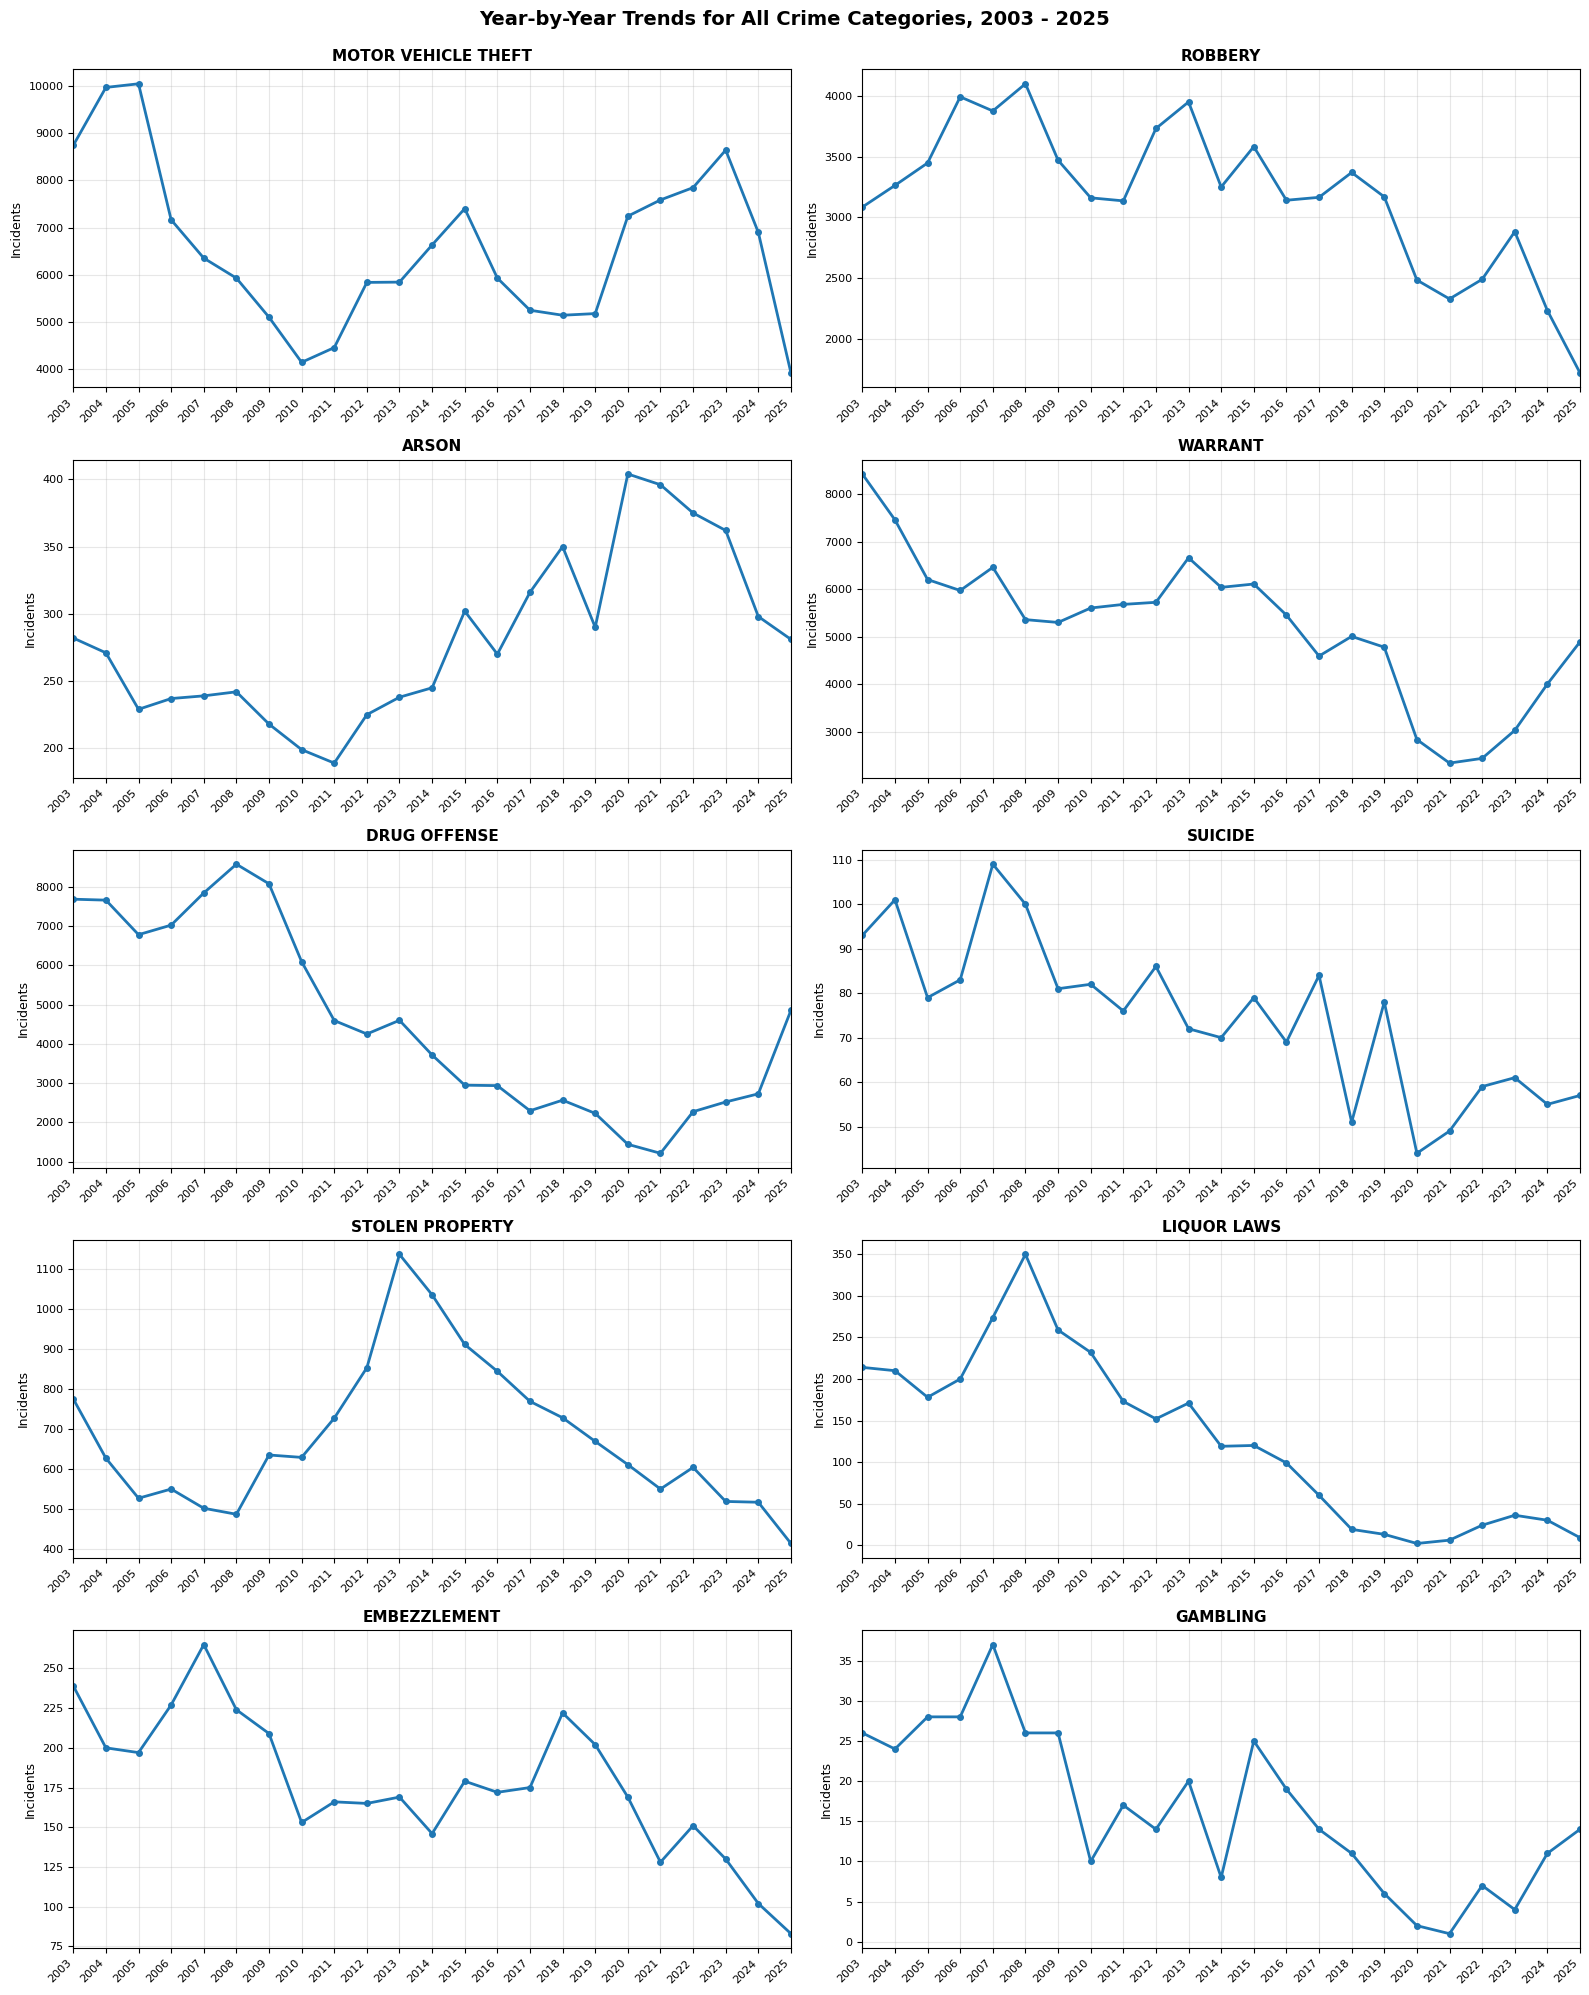

In [4]:
# Get the categories of the dataset
categories = df["Incident Category"].unique()

# Number of unique categories
n_categories = len(categories)
cols = 2
rows = math.ceil(n_categories / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()

# Loop through each category and plot the yearly trend
for idx, category in enumerate(categories):
    ax = axes[idx]
    
    category_data = df[df["Incident Category"] == category]
    yearly_counts = category_data["Incident Year"].value_counts().sort_index()
    
    ax.plot(yearly_counts.index, yearly_counts.values, marker='o', linewidth=2, markersize=4)
    
    # Set x-ticks to show every year from 2003 to 2025
    years_list = list(range(2003, 2026))
    ax.set_xticks(years_list)
    
    ax.set_xticklabels(years_list, rotation=45, ha='right')

    ax.set_xlim(2003, 2025)
    
    ax.set_title(category, fontsize=11, fontweight='bold')
    ax.set_ylabel("Incidents", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)

for idx in range(n_categories, len(axes)):
    axes[idx].axis('off')

plt.suptitle("Year-by-Year Trends for All Crime Categories, " + str(df["Incident Year"].min()) + " - " + str(df["Incident Year"].max()), fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

The figures above shows year by year trends for the focus crimes chosen (MOTOR VEHICLE THEFT, ROBBERY, ARSON, WARRANT, DRUG OFFENSE, SUICIDE, STOLEN PROPERTY, LIQUOR LAWS, EMBEZZLEMENT, GAMBLING). Year by year trends are shown for the period 2003-2025. 

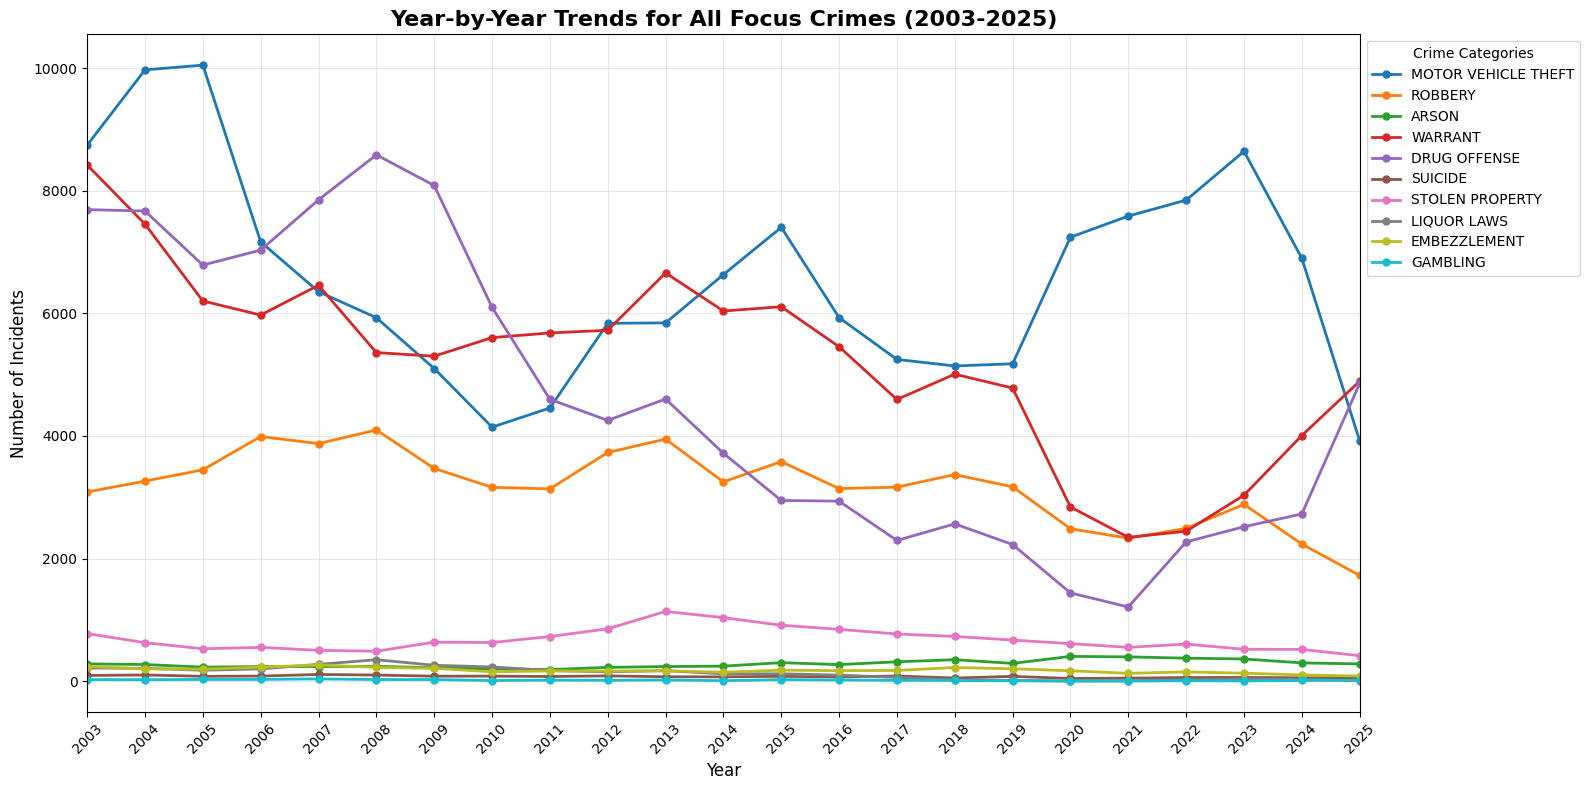

In [5]:
# Plotting all categories on the same graph for comparison
plt.figure(figsize=(16, 8))
all_years = list(range(2003, 2026))

# Loop through each category and plot the yearly trend on the same graph
for category in categories:
    category_data = df[df["Incident Category"] == category]
    yearly_counts = category_data["Incident Year"].value_counts().reindex(all_years, fill_value=0).sort_index()
    plt.plot(yearly_counts.index, yearly_counts.values, marker='o', linewidth=2, markersize=5, label=category)

# Set visualization parameters
plt.xticks(all_years, rotation=45)
plt.xlim(2003, 2025)
plt.title("Year-by-Year Trends for All Focus Crimes (2003-2025)", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title="Crime Categories", loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
plt.tight_layout()
plt.show()

Unified representation of the trends for a quick look into how they developed through the years.

***Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.***

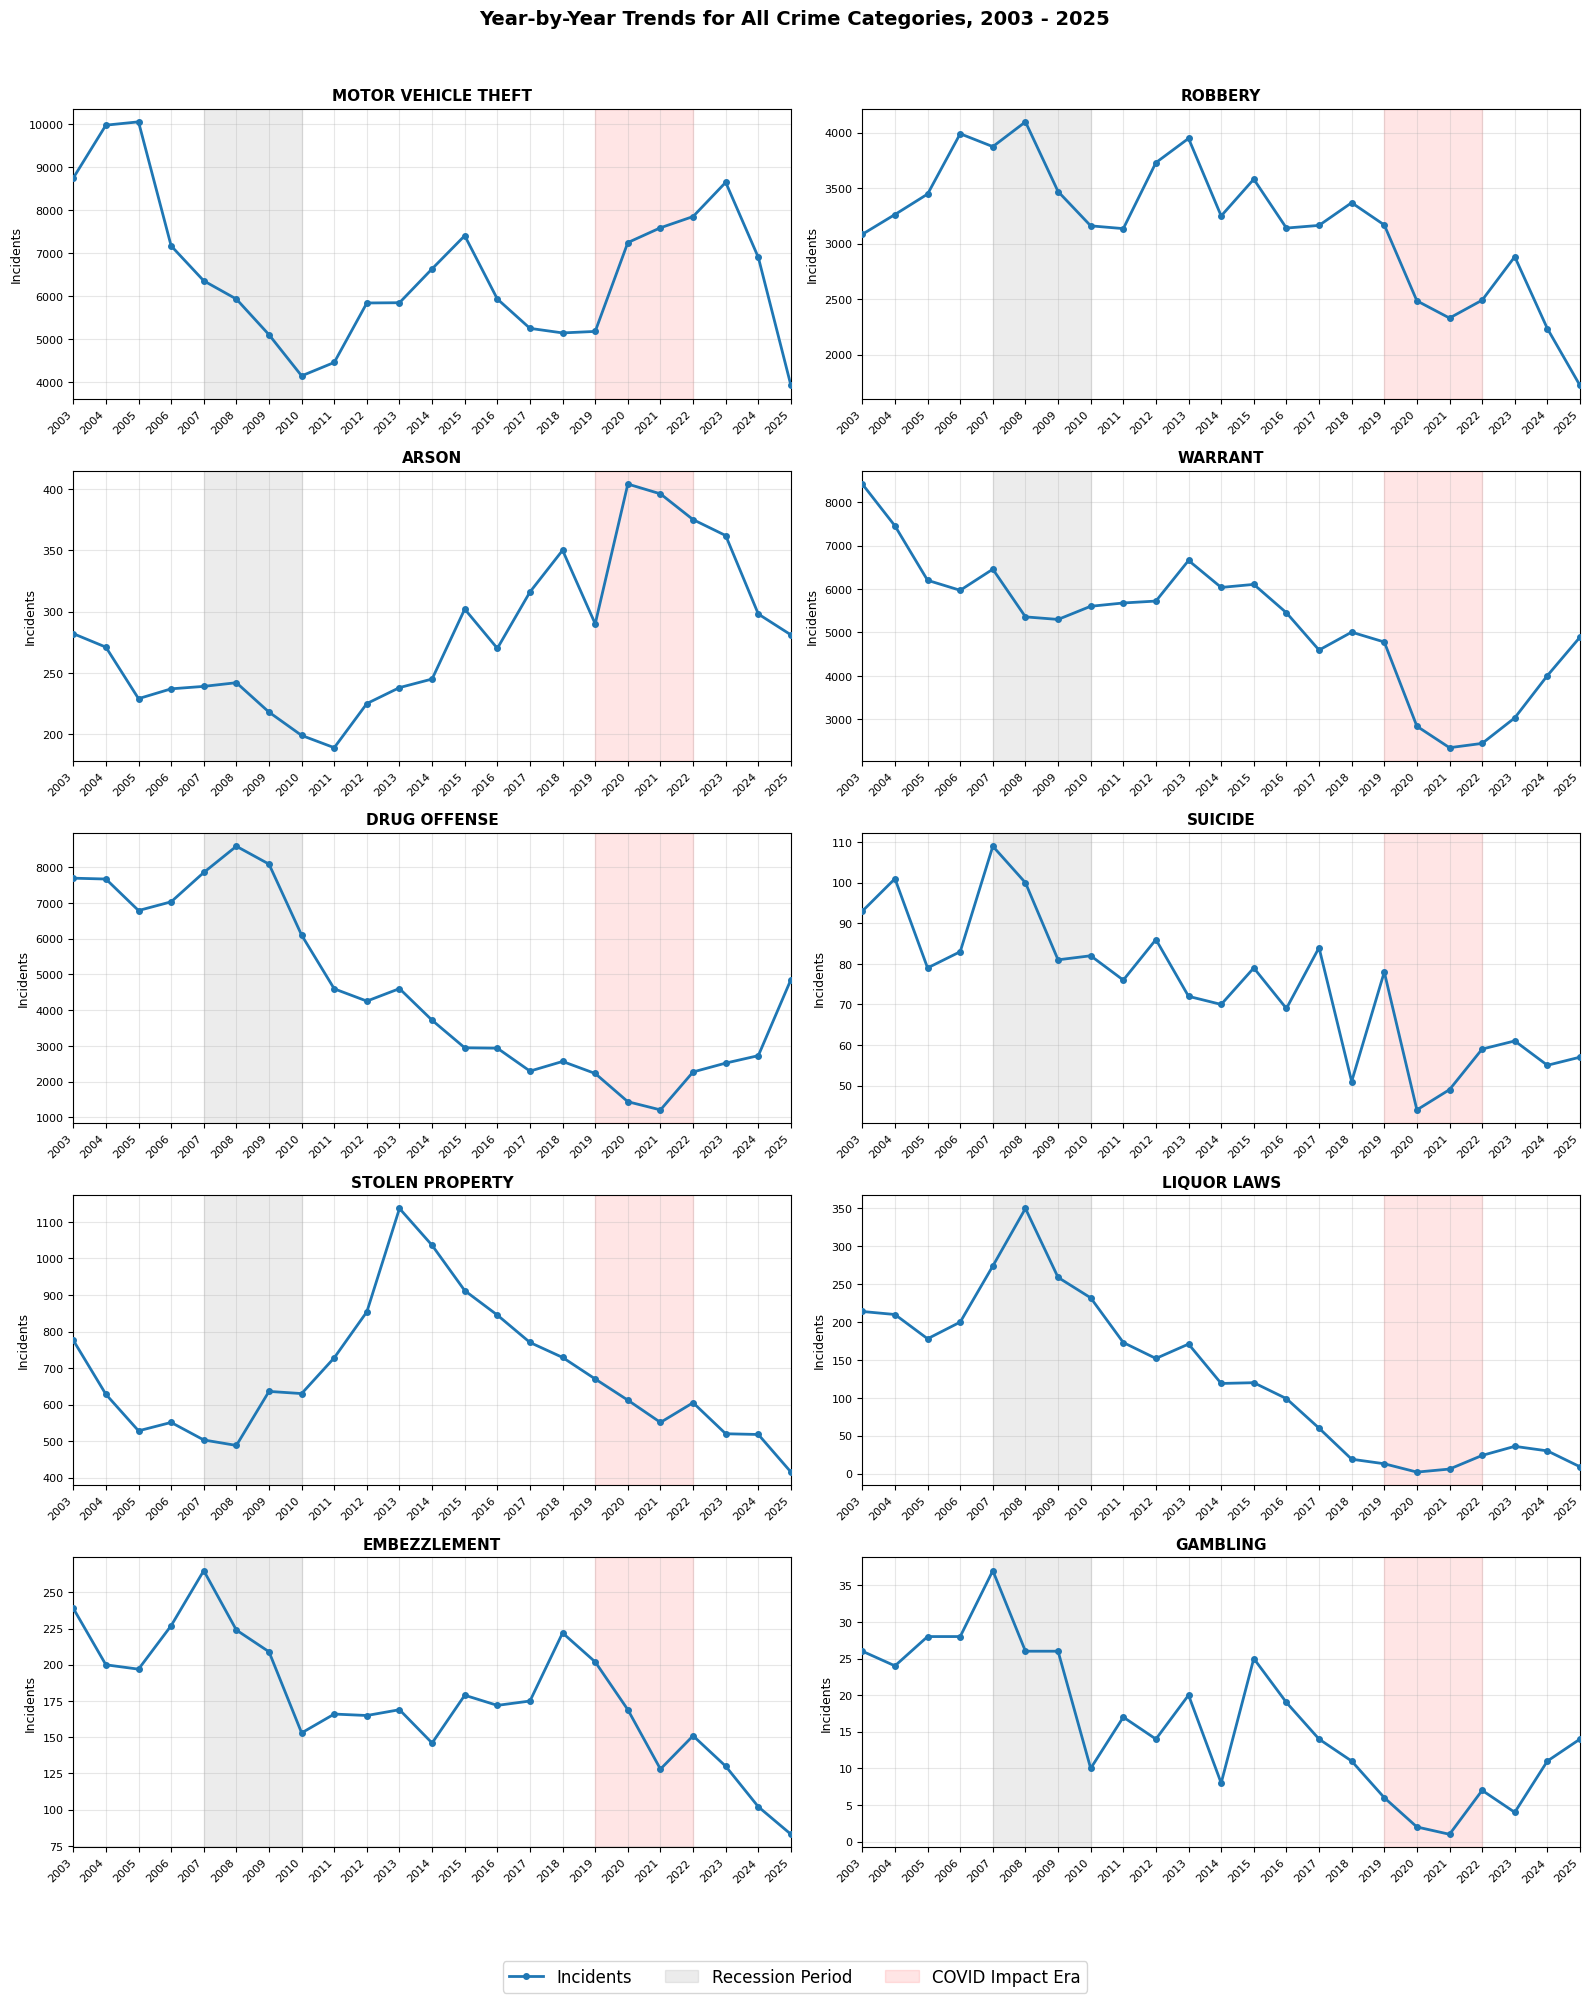

In [6]:
# Individual subplots with recession and COVID-19 impact periods highlighted
cols = 2
rows = math.ceil(n_categories / cols)
fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()

years_list = list(range(2003, 2026))

# Loop through each category and plot the yearly trend with recession and COVID-19 impacts periods
for idx, category in enumerate(categories):
    ax = axes[idx]
    
    category_data = df[df["Incident Category"] == category]
    yearly_counts = category_data["Incident Year"].value_counts().sort_index()

    ax.plot(yearly_counts.index, yearly_counts.values, marker='o', linewidth=2, markersize=4, label='Incidents', zorder=3)

    # Highlight recession and COVID-19 impact periods
    ax.axvspan(2007, 2010, color='gray', alpha=0.15, label='Recession Period') # Financial Crisis: 2007 (Before) to 2010 (After/Recovery)
    ax.axvspan(2019, 2022, color='red', alpha=0.1, label='COVID Impact Era')   # COVID-19: 2019 (Before) to 2022 (Recovery phase)
    
    ax.set_xticks(years_list)
    ax.set_xticklabels(years_list, rotation=45, ha='right')
    ax.set_xlim(2003, 2025)
    ax.set_title(category, fontsize=11, fontweight='bold')
    ax.set_ylabel("Incidents", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)
    
for idx in range(n_categories, len(axes)):
    axes[idx].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12)

plt.suptitle("Year-by-Year Trends for All Crime Categories, " + str(df["Incident Year"].min()) + " - " + str(df["Incident Year"].max()), fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0.05, 1, 0.98]) 
plt.show()

The figure above shows year-by-year trends with two historical time periods which are highlighted:
1) Financial Crisis: 2007 (Before) to 2010 (After/Recovery)
2) COVID-19: 2019 (Before) to 2022 (Recovery phase)


The grey-shaded area illustrates how crime patterns shifted during a period of severe global economic stress.

* Observations: While MOTOR VEHICLE THEFT and EMBEZZLEMENT declined significantly during this period, LIQUOR LAWS and DRUG OFFENSE increased and peaked between 2008 and 2009.

* Explanation: Economic downturns often lead to increased activity in “underground” economies or substance-related incidents as unemployment and financial hardship rise. This “stress-response” theory explains the peak in LIQUOR LAWS and DRUG OFFENSE during the crisis.  Conversely, the decline in MOTOR VEHICLE THEFT likely reflects reduced mobility and fewer high-value targets on the streets as consumer spending and vehicle usage changed during the recession.

Almost every subplot highlights the dramatic shock caused by the pandemic, particularly starting in 2020.

* Observations: Categories like ROBBERY, WARRANT, DRUG OFFENSE, and LIQUOR LAWS show sharp declines or deep troughs during the red-shaded window. ARSON, however, reaches a historical peak during the same period.

* Explanation: The “stay at home” orders and widespread closure of the hospitality industry (bars and nightclubs) dramatically changed the urban landscape. Many crimes are “opportunity-based” and require public interaction or density.  With fewer pedestrians and closed businesses, the physical opportunity for street-level robbery and liquor violations dropped. However, the rise in ARSON suggests that while interpersonal crimes fell due to social isolation, property-related acts of social frustration or opportunism in empty areas may have increased.


## Assignment 1.2: Crime Profiles by Police District

***For each police district in your dataset, compute the conditional crime profile***

 $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$

In [7]:
# Filter the DataFrame to include only rows where 'Police District' is one of the official districts
official_districts = [
    'NORTHERN', 'PARK', 'INGLESIDE', 'BAYVIEW', 'RICHMOND', 
    'CENTRAL', 'TARAVAL', 'TENDERLOIN', 'MISSION', 'SOUTHERN'
]
df_clean = df[df['Police District'].isin(official_districts)].copy()

In [9]:
# Compute the overall probability of each crime category in the cleaned dataset
p_crime = df_clean['Incident Category'].value_counts(normalize=True)

# Print up to 4 decimal places for better readability
print(p_crime.round(4))

Incident Category
MOTOR VEHICLE THEFT    0.3140
WARRANT                0.2505
DRUG OFFENSE           0.2186
ROBBERY                0.1520
STOLEN PROPERTY        0.0324
ARSON                  0.0135
EMBEZZLEMENT           0.0084
LIQUOR LAWS            0.0061
SUICIDE                0.0036
GAMBLING               0.0008
Name: proportion, dtype: float64


In [14]:
# Group by District AND Category, find the proportion of each crime within each district
p_crime_given_district = df_clean.groupby('Police District')['Incident Category'].value_counts(normalize=True).unstack(fill_value=0)

# Calculate the ratio of P(crime | district) to P(crime) for each crime category and district
r = p_crime_given_district / p_crime

# Print up to 4 decimal places for better readability
print(r.round(4))

Incident Category   ARSON  DRUG OFFENSE  EMBEZZLEMENT  GAMBLING  LIQUOR LAWS  \
Police District                                                                
BAYVIEW            1.9760        0.6858        1.0280    1.3392       0.7201   
CENTRAL            1.2491        0.5228        1.9550    2.2219       0.9330   
INGLESIDE          1.0544        0.4177        0.5835    1.7081       0.4485   
MISSION            0.8267        1.0807        0.7360    0.8254       1.8905   
NORTHERN           1.0578        0.8092        0.9583    0.5683       0.5351   
PARK               0.7429        0.8496        0.6619    0.1057       1.4088   
RICHMOND           1.3142        0.4259        1.0393    0.7991       0.5290   
SOUTHERN           0.7980        1.1319        1.3372    0.6822       1.3462   
TARAVAL            1.1831        0.4196        1.2695    1.0450       0.4352   
TENDERLOIN         0.3951        2.1913        0.6960    0.8237       0.8668   

Incident Category  MOTOR VEHICLE THEFT 

***Visualize these ratios in a way that makes it easy to compare across both districts and crime types.***

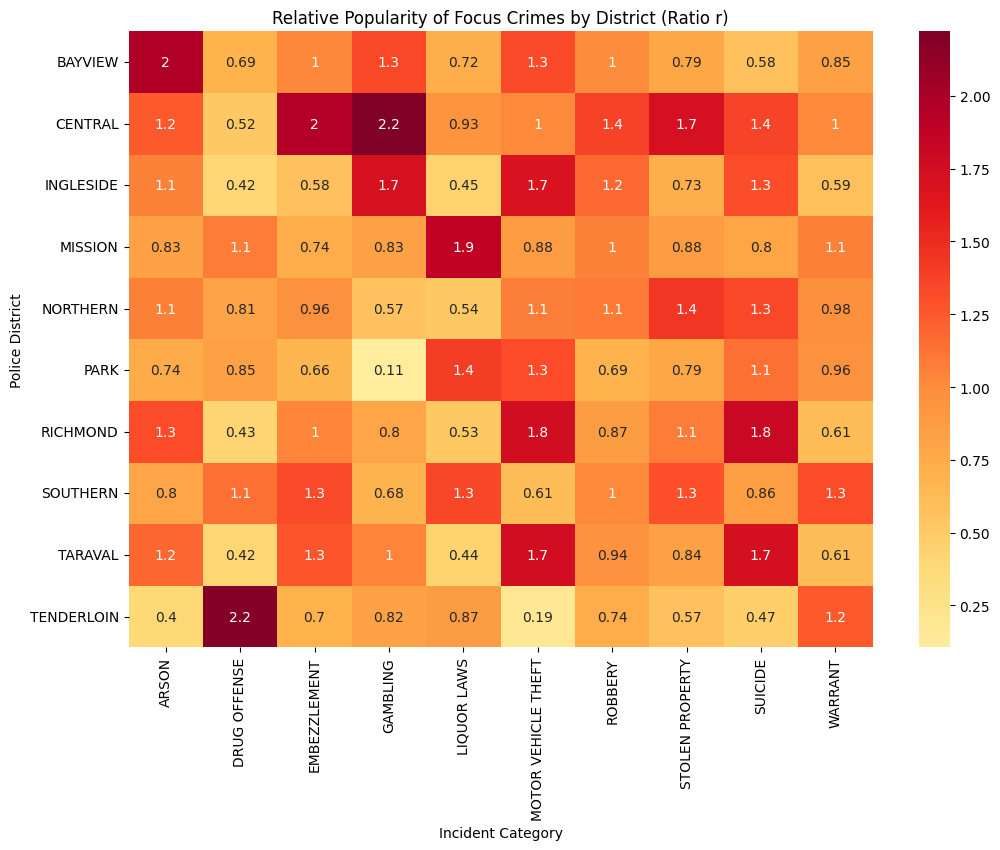

In [15]:
plt.figure(figsize=(12, 8))

# Create a heatmap of the ratio r 
sns.heatmap(r, annot=True, cmap="YlOrRd", center=1)
plt.title("Relative Popularity of Focus Crimes by District (Ratio r)")
plt.show()

The figure above illustrates the relative popularity of focus crimes across the ten different Police Districts in San Francisco for the period 2003–2025. The values represent the ratio (r), which measures how prevalent a crime category is in a specific district compared to the city-wide average. A ratio of r=1 indicates that the crime occurs at the expected average rate, while r>1 signifies a higher concentration and r<1 signifies a lower concentration of that incident category within the district.

***Pick one district whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?***

By examining the relative popularity ratios (r), there are two districts that serve as opposites in terms of their criminal signatures: the Tenderloin and the Central District. While they are geographically close, their socio-economic and urban environments create very different data profiles.

The Tenderloin stands out as a significant statistical outlier, defined by high-visibility street activity and a lack of traditional property targets.
* Key Observations:
    * Drug Offences (r=2.2): This is the highest ratio in the city, indicating that drug-related incidents are more than twice as likely to occur here relative to the city average.
    * Motor Vehicle Theft (r=0.19): Tenderloin has the lowest relative frequency of vehicle theft in San Francisco.
* Explanation and Factors:
    * Geographic Density: The area’s high population density make it a frequent location for street-level activity. This makes crimes like drug deals very easy for the police to see and report.
    * Urban Layout: For car theft, thieves typically target quiet residential areas with a low crime rate, such as Richmond (r=1.75). The presence of a large number of people in the Tenderloin makes it an unsuitable location for a thief to spend time breaking into a vehicle.

The Central District is the city’s financial and tourism hub. Its profile is characterised by high-value targets.
* Key Observations:
    * Gambling (r=2.2) and Embezzlement (r=2): Central holds the city’s highest ratios for these categories, reflecting its role as a financial and cultural hub.
    * Stolen Property (r=1.7) and Robbery (r=1.4): These ratios are significantly elevated compared to residential districts.
    * Drug Offences (r=0.52): Despite high foot traffic, drug-related incidents are nearly 50% below the city average.
* Explanation and Factors:
    * Economic Infrastructure: The peak in embezzlement is directly linked to the concentration of banking and corporate headquarters in the Financial District. These are ‘crimes of access’ that require a corporate environment to exist.
    * Tourist hubs attract a large number of visitors carrying expensive electronics and cash, creating a high-risk environment for robbery and theft.
    * The low drug offence ratio is likely a result of intensive security in the city centre. This often pushes street-level drug activity out of Central and into the neighbouring Tenderloin.

## Assignment 1.3: Visualizing Distributions

### Time Feature Extraction

In [16]:
# Convert Time to datetime
df['Incident Time'] = pd.to_datetime(df['Incident Time'], format='%H:%M', errors='coerce')

# Extract hours for all data
df['Hour'] = df['Incident Time'].dt.hour

# Extract minutes for all data
df['Minute'] = df['Incident Time'].dt.minute

# There are no seconds in the dataset

### Part A - Jitter Plot
***Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the -axis and add vertical jitter.***

#### Selection of the focus crime

In [17]:
# Select crime type and time period (DRUG OFFENSE, considering 6 months)
crime_type = 'DRUG OFFENSE'
crime_data = df[(df['Incident Category'] == crime_type) & 
                (df['Incident Date'] >= '2024-01-01') & 
                (df['Incident Date'] <= '2024-06-30')].copy()

# Print the amount of crimes in the selected period
print(f"Total {crime_type} incidents in the selected period: {len(crime_data)}")

Total DRUG OFFENSE incidents in the selected period: 1323


#### Visualization of the Jitter Plot

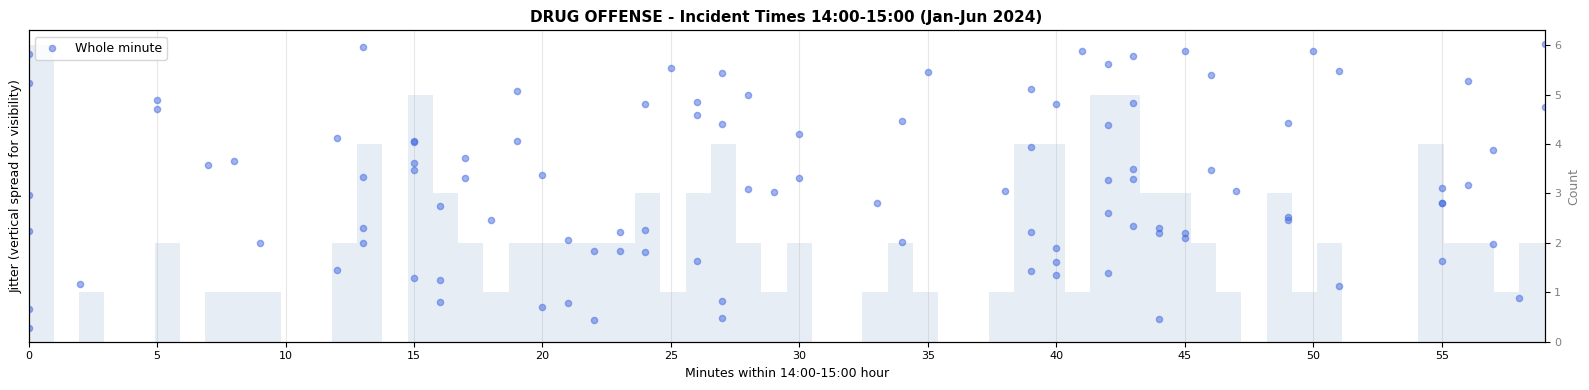

In [18]:
# Filter for a specific hour (in this case, 14:00-15:00)
hour_data = crime_data[crime_data['Hour'] == 14].copy()

# Create jitter plot
fig, ax = plt.subplots(figsize=(16, 4))

jitter = np.random.uniform(-0.4, 0.4, size=len(hour_data))

# Adaptation of the visualization to show the histogram behind the jitter plot

# Histogram behind
ax2 = ax.twinx()
ax2.hist(hour_data['Minute'], bins=60, range=(0, 59), color='lightsteelblue', 
         alpha=0.3, zorder=1, label='Frequency')
ax2.set_ylabel('Count', fontsize=9, color='gray')
ax2.tick_params(axis='y', labelcolor='gray', labelsize=8)
ax2.set_zorder(1)

# Jitter plot in front
ax.set_zorder(2) 
ax.patch.set_visible(False)  # make scatter background transparent

ax.scatter(hour_data['Minute'], jitter,
           alpha=0.5, s=20, color='royalblue', label='Whole minute', zorder=2)

# This part must be changed in case of selecting another time (manual)
ax.set_xlabel('Minutes within 14:00-15:00 hour', fontsize=9)
ax.set_ylabel('Jitter (vertical spread for visibility)', fontsize=9)
ax.set_title(f'{crime_type} - Incident Times 14:00-15:00 (Jan-Jun 2024)', fontsize=11, fontweight='bold')
ax.set_yticks([])
ax.set_xlim(0, 59)
ax.set_xticks(range(0, 60, 5))
ax.tick_params(labelsize=8)
ax.grid(axis='x', alpha=0.3)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

The figure above is a jitter plot showing DRUG OFFENSE incident times within 14:00-15:00 hour. Behind it, the faded histogram shows the frequency of incidents per minute to allow a better visualization of the distribution.

***What does the jitter plot reveal about how times are recorded in the dataset?***

The precision at which the police register the incidents do not reach the seconds, and limits itself to the minutes.

***Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?***

The jitter plot shows that data has a precision at the level of minutes, being registered through the whole 60 minutes gap without clear incidents of clustering. In this particular case (14:00-15:00) it might seem that some data is clustered around :00, but once other hours are checked, that behavior does not continue.

### Part B - Probability Plot
***Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types***

The crimes selected were DRUG OFFENSE and LIQUOR LAWS. While doing the weekly exercises, they showed a different behavior across districts. Therefore the interest into analyzing them.

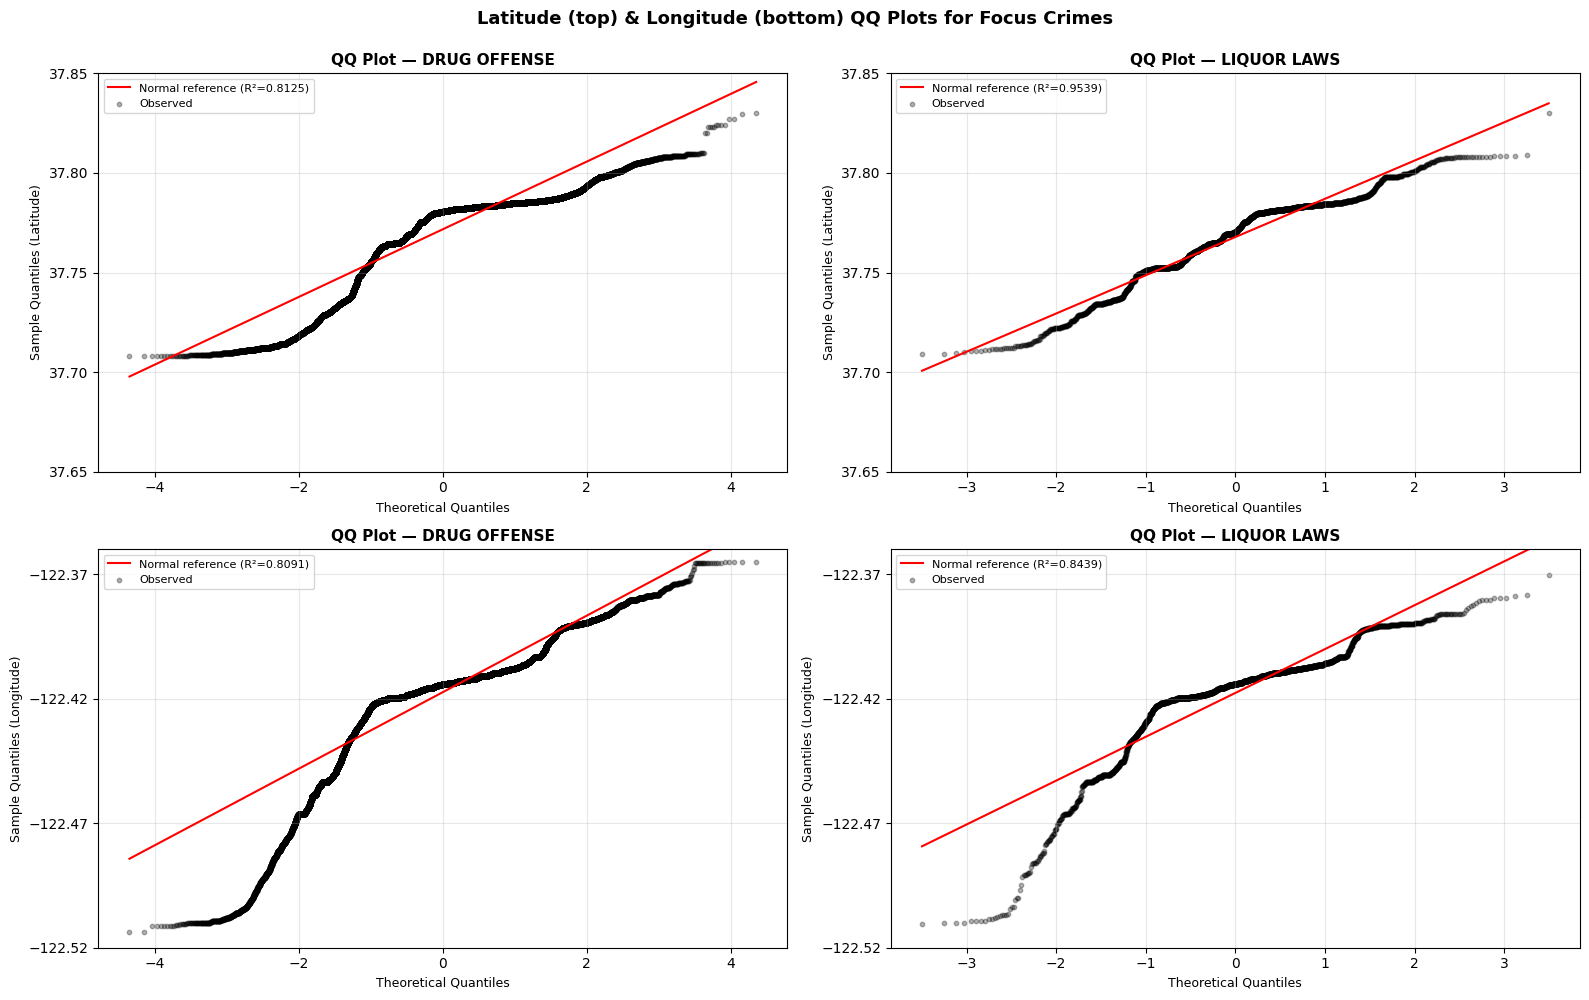

In [20]:
# Select the two crimes of interest for the QQ plot
crimes_of_interest = ['DRUG OFFENSE', 'LIQUOR LAWS']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Remove impossible coordinates (limit to San Francisco area)
for col, crime in enumerate(crimes_of_interest):
    valid_data = df[
        (df['Incident Category'] == crime) &
        (df['Latitude']  > 37.0) & (df['Latitude']  < 38.0) &
        (df['Longitude'] > -123.0) & (df['Longitude'] < -122.0)
    ].dropna(subset=['Latitude', 'Longitude'])

    # For Latitude QQ plot
    ax = axes[0, col]

    # Calculate the quantiles and the reference line for the normal distribution
    (osm, osr), (slope, intercept, r) = stats.probplot(valid_data['Latitude'].values, dist='norm')
    
    # Plot the reference line for the normal distribution
    ax.plot(osm, slope * np.array(osm) + intercept, color='red',
            linewidth=1.5, label=f'Normal reference (R²={r**2:.4f})')
    
    # Plot the coordinates of the observed data points
    ax.scatter(osm, osr, alpha=0.3, s=10, color='black', label='Observed')

    # Titles and labels
    ax.set_title(f'QQ Plot — {crime}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles', fontsize=9)
    ax.set_ylabel('Sample Quantiles (Latitude)', fontsize=9)
    ax.set_ylim(37.65, 37.85)
    ax.set_yticks(np.arange(37.65, 37.86, 0.05))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # ADDITIONAL: For Longitude QQ plot
    ax = axes[1, col]

    # Calculate the quantiles and the reference line for the normal distribution
    (osm, osr), (slope, intercept, r) = stats.probplot(valid_data['Longitude'].values, dist='norm')
    
    # Plot the reference line for the normal distribution
    ax.plot(osm, slope * np.array(osm) + intercept, color='red',
            linewidth=1.5, label=f'Normal reference (R²={r**2:.4f})')
    
    # Plot the coordinates of the observed data points
    ax.scatter(osm, osr, alpha=0.3, s=10, color='black', label='Observed')

    # Titles and labels
    ax.set_title(f'QQ Plot — {crime}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles', fontsize=9)
    ax.set_ylabel('Sample Quantiles (Longitude)', fontsize=9)
    ax.set_ylim(-122.52, -122.36)
    ax.set_yticks(np.arange(-122.52, -122.36, 0.05))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Latitude (top) & Longitude (bottom) QQ Plots for Focus Crimes', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

The figure above shows QQ plots comparing the distribution of Latitude and Longitude for DRUG OFFENSE and LIQUOR LAWS incidents against a normal distribution. The red line represents the expected quantiles if the data were normally distributed, with R² values indicating the goodness of fit.

***What reference distribution are you comparing against?***

We are comparing against the normal distribution.

***What would it mean if the points fell exactly on the straight line?***

That would mean that all data is normally distributed, that is, the crimes would not be clustered on certain zones. That could imply that geography does not play a deep role on explaining why the crimes occur, and that no hotspots exist, which could lead to generic laws and policies instead of more focused actions to tackle the crimes.

***Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?***

It can be seen that, for both crimes, there is a bigger deviation in the longitude than in the latitude. The tails that exist (kind of S-shape) can indicate that the crime distribution is concentrated in certain locations, implying the existance of hotspots (as could be expected in real life). In these particular examples, the flat part of the tails can indicate crime clusters, meaning that crime locations are geographically constrained and are not distributed evenly.

### Part C — Box plots of time-of-day

***For each of your Personal Focus Crimes, extract the time-of-day of every incident.***

***Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.***


#### Visualization of the Focus Crimes (boxplot)

C:\Users\ogonz\AppData\Local\Temp\ipykernel_39344\704822770.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot,


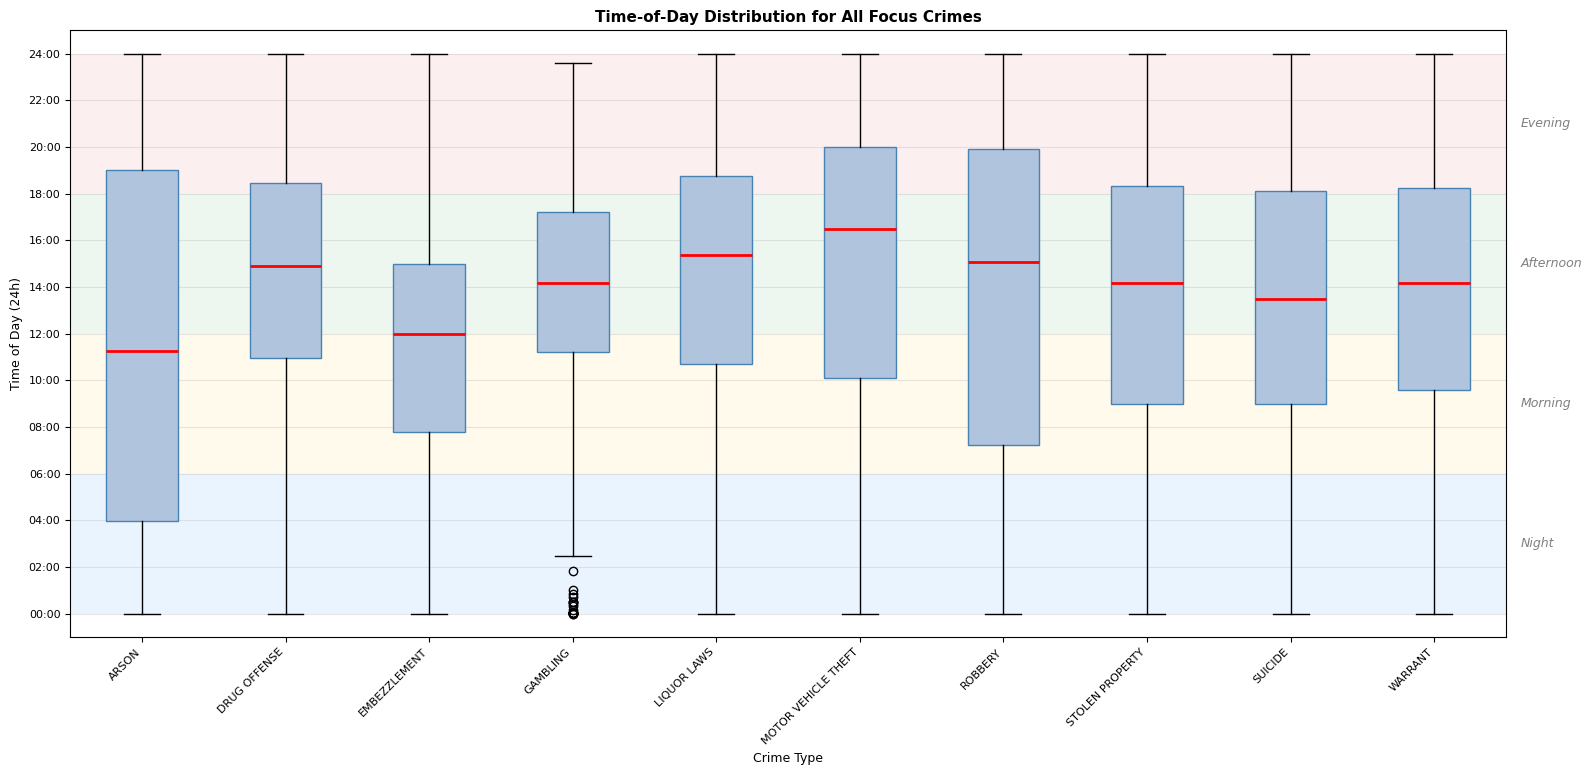

In [21]:
# Get all unique crime categories (already filtered for focus crimes in the dataset)
all_crimes = sorted(df['Incident Category'].unique())

# Convert to minutes since midnight (for a correct time-of-day analysis)
df['Minutes_since_midnight'] = df['Hour'] * 60 + df['Minute']

# Define time-of-day periods (in minutes)
periods = [
    (0,      6*60,  'Night',     '#cce5ff'),
    (6*60,  12*60,  'Morning',   '#fff3cd'),
    (12*60, 18*60,  'Afternoon', '#d4edda'),
    (18*60, 24*60,  'Evening',   '#f8d7da'),
]

# Drop rows with missing time data for the crime categories
data_to_plot = [
    df[df['Incident Category'] == crime]['Minutes_since_midnight'].dropna().values
    for crime in all_crimes
]

# Create plot
fig, ax = plt.subplots(figsize=(16, 8))

# Add background shading for each period
for start, end, label, color in periods:
    ax.axhspan(start, end, facecolor=color, alpha=0.4, zorder=0)
    ax.text(len(all_crimes) + 0.6, (start + end) / 2, label,
            va='center', ha='left', fontsize=9, color='gray', style='italic')

ax.boxplot(data_to_plot,
           labels=all_crimes,
           patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
           medianprops=dict(color='red', linewidth=2),
           zorder=2)

# Y-axis in hours
hours = range(0, 25, 2)
ax.set_yticks([h * 60 for h in hours])
ax.set_yticklabels([f'{h:02d}:00' for h in hours], fontsize=8)
ax.set_ylim(-1 * 60, 25 * 60)

ax.set_xlabel('Crime Type', fontsize=9)
ax.set_ylabel('Time of Day (24h)', fontsize=9)
ax.set_title('Time-of-Day Distribution for All Focus Crimes', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.tick_params(labelsize=8)
plt.xticks(rotation=45, ha='right')
plt.suptitle('', y=0.995)
plt.tight_layout()
plt.show()

The figure above is a box plot showing the distribution of incident times (through the day) for all crime categories. Background colors indicate different time-of-day periods (Night, Morning, Afternoon, Evening) to facilitate interpretation of when incidents are more likely to occur.

### Visualization of Focus Crimes in raincloud plots

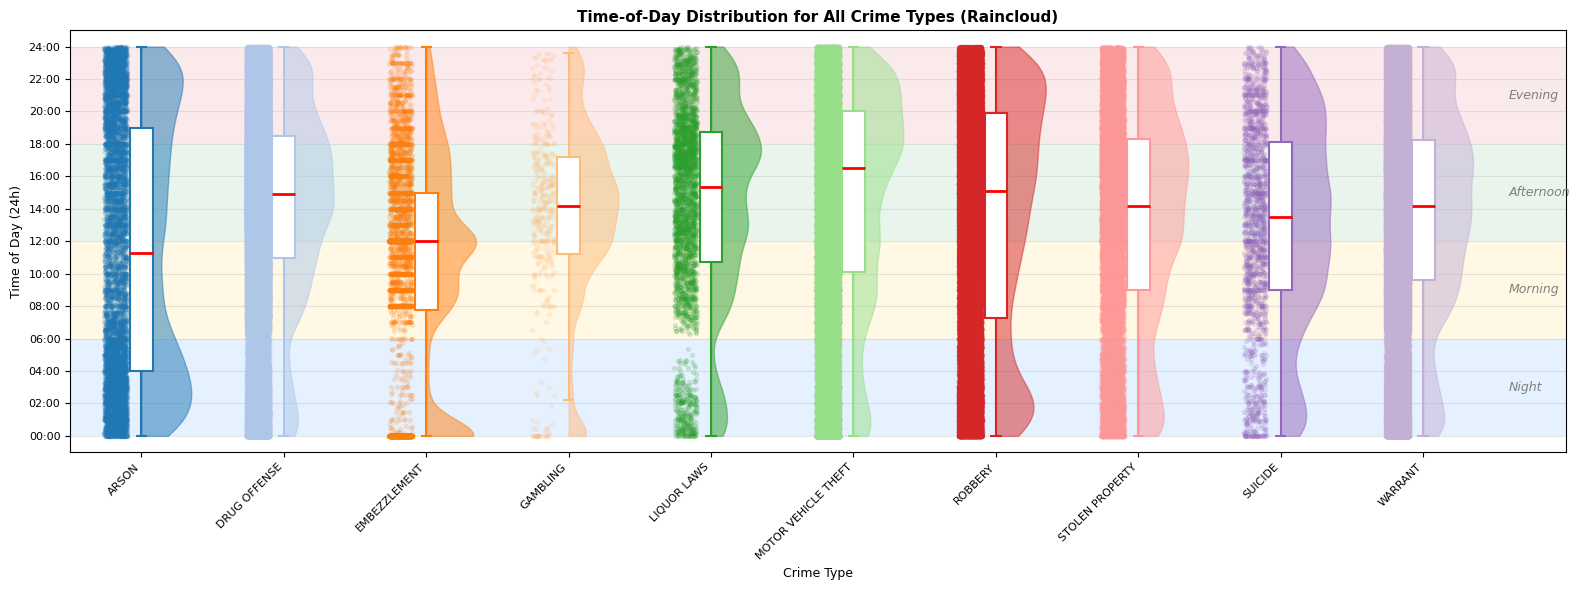

In [22]:

# Drop rows with missing time data for the crime categories
plot_data = df.dropna(subset=['Minutes_since_midnight'])

# Generate colors dynamically for all crimes
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(len(all_crimes))]

# Y-axis range in minutes
y_range = np.linspace(0, 24 * 60, 500)

# Start of the plot
fig, ax = plt.subplots(figsize=(16, 6))

# Background period shading
for start, end, label, color in periods:
    ax.axhspan(start, end, facecolor=color, alpha=0.5, zorder=0)
    ax.text(len(all_crimes) + 0.6, (start + end) / 2, label,
            va='center', ha='left', fontsize=9, color='gray', style='italic')

# Plot each crime type with its own color
for i, (crime, color) in enumerate(zip(all_crimes, colors)):
    x_pos = i + 1
    values = plot_data[plot_data['Incident Category'] == crime]['Minutes_since_midnight'].values

    # Skip if the data points are not enough for KDE
    if len(values) < 2:
        continue

    # KDE (density) plot
    kde = gaussian_kde(values, bw_method=0.15)
    kde_vals = kde(y_range)
    kde_vals_scaled = kde_vals / kde_vals.max() * 0.35
    ax.fill_betweenx(y_range, x_pos, x_pos + kde_vals_scaled,
                     alpha=0.5, color=color, zorder=2)

    # Boxplot
    q1, median, q3 = np.percentile(values, [25, 50, 75])
    iqr = q3 - q1
    lower_whisker = max(values.min(), q1 - 1.5 * iqr)
    upper_whisker = min(values.max(), q3 + 1.5 * iqr)

    # Manual display of boxplot
    box_width = 0.08
    ax.add_patch(plt.Rectangle((x_pos - box_width, q1), box_width * 2, iqr,
                                facecolor='white', edgecolor=color, linewidth=1.5, zorder=3))
    ax.hlines(median, x_pos - box_width, x_pos + box_width,
              color='red', linewidth=2, zorder=4)
    ax.vlines(x_pos, lower_whisker, q1, color=color, linewidth=1.5, zorder=3)
    ax.vlines(x_pos, q3, upper_whisker, color=color, linewidth=1.5, zorder=3)
    ax.hlines([lower_whisker, upper_whisker], x_pos - box_width / 2, x_pos + box_width / 2,
              color=color, linewidth=1.5, zorder=3)

    # Jitter plot
    jitter = np.random.uniform(-0.08, 0.08, size=len(values))
    ax.scatter(x_pos - 0.18 + jitter, values,
               alpha=0.15, s=8, color=color, zorder=2)

# Y-axis in hours
hours = range(0, 25, 2)
ax.set_yticks([h * 60 for h in hours])
ax.set_yticklabels([f'{h:02d}:00' for h in hours], fontsize=8)
ax.set_ylim(-1 * 60, 25 * 60)

# X-axis with all crime types
ax.set_xticks(range(1, len(all_crimes) + 1))
ax.set_xticklabels(all_crimes, rotation=45, ha='right', fontsize=8)
ax.set_xlim(0.5, len(all_crimes) + 1)

# Final labels and title
ax.set_xlabel('Crime Type', fontsize=9)
ax.set_ylabel('Time of Day (24h)', fontsize=9)
ax.set_title('Time-of-Day Distribution for All Crime Types (Raincloud)', fontsize=11, fontweight='bold')
ax.tick_params(labelsize=8)
ax.grid(axis='y', alpha=0.3, zorder=1)
plt.tight_layout()
plt.show()

The figure above is a raincloud plot showing the distribution of incident times for all crime categories. Each crime type has its own color, with KDE density plots, boxplots, and jittered individual points. Background colors indicate different time-of-day periods (Night, Morning, Afternoon, Evening) to facilitate interpretation of when incidents are more likely to occur. In some cases (Ex. ROBBERY), the individual jitter points are not visible due to the density of incidents across the day (and the amount of values it has).

### Visualization of Focus Crimes in Polar Histogram

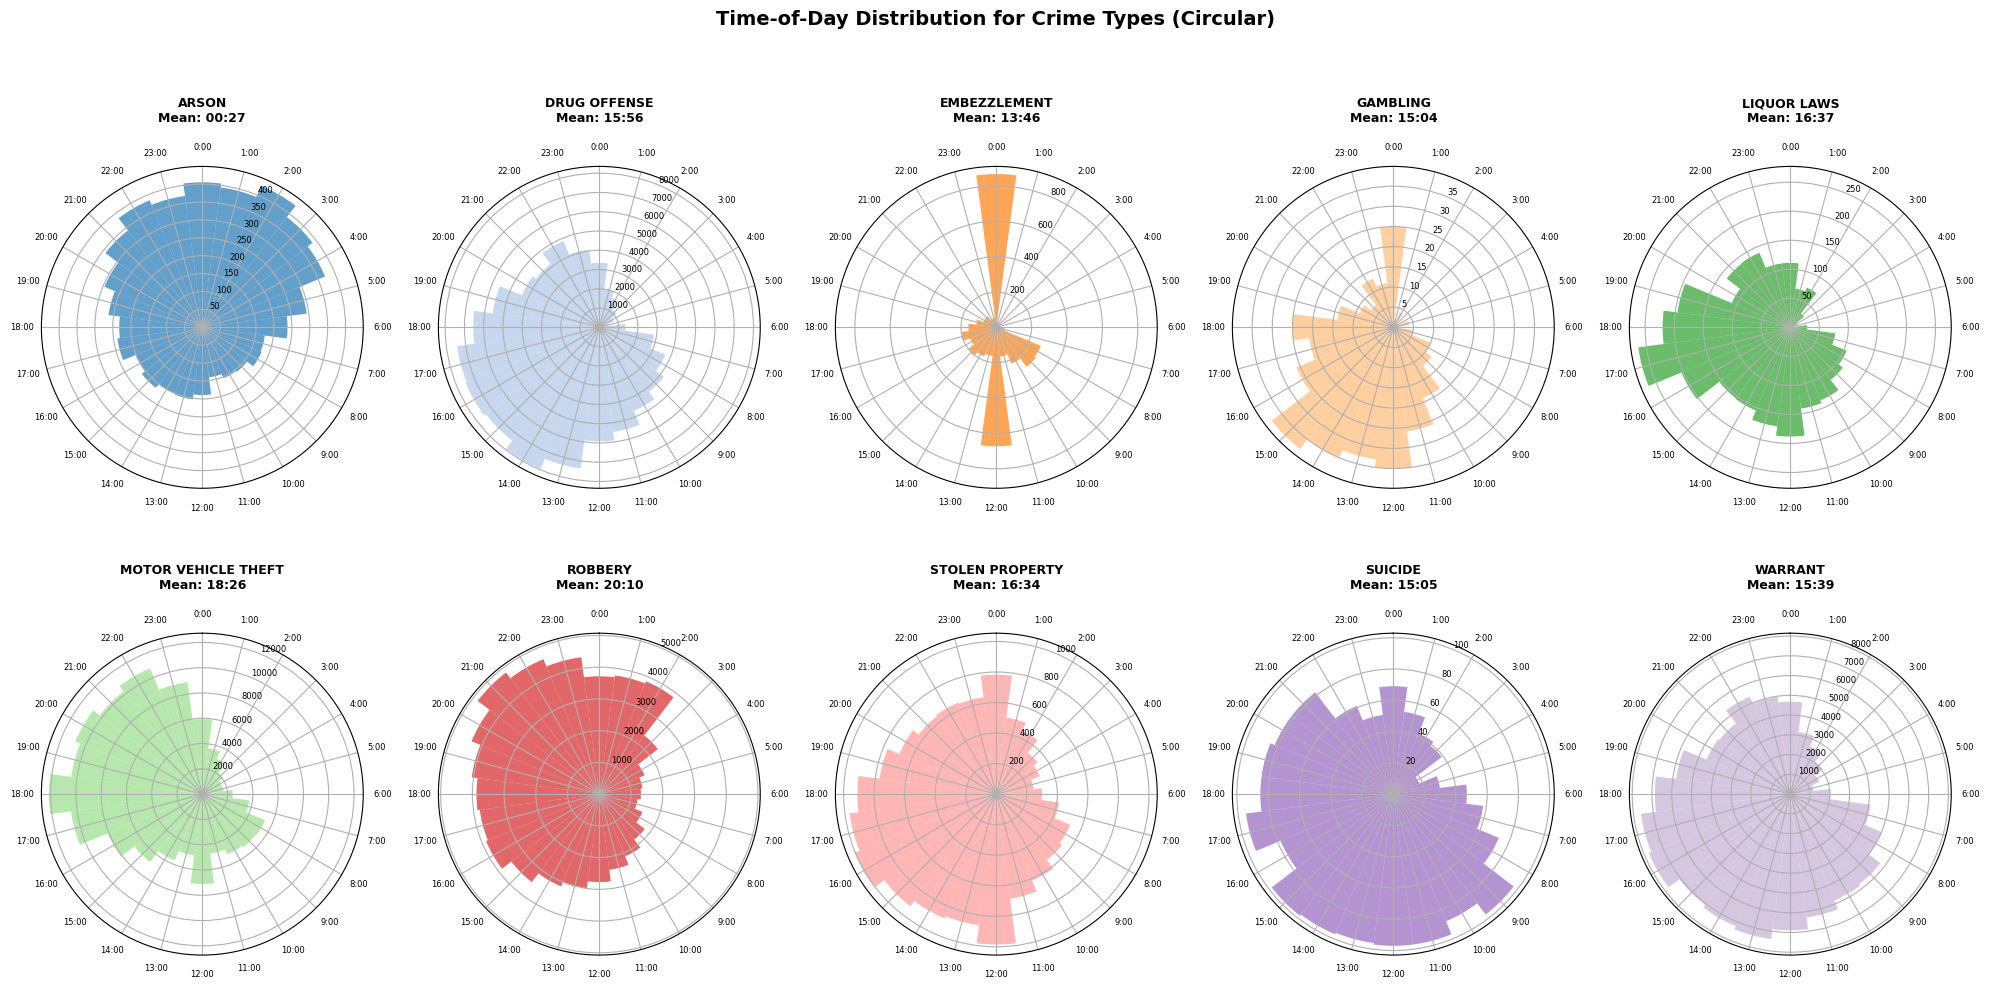

In [23]:
# Convert times to angles (radians)
df['Time_angle'] = df['Minutes_since_midnight'].apply(
    lambda x: (x / (24 * 60)) * 2 * np.pi if pd.notna(x) else None
)

# Drop rows with missing time data for the crime categories
crime_times = df[['Incident Category', 'Time_angle']].dropna()

# Calculate circular statistics for each crime

# Initiate list to store results
results = []

# Loop through each crime type to calculate circular mean time
for crime in all_crimes:
    angles = crime_times[crime_times['Incident Category'] == crime]['Time_angle'].values
    
    # Skip if there is no data for the crime
    if len(angles) == 0:
        results.append({'Crime': crime, 'Circular Mean Time': 'N/A'})
        continue

    # Circular mean
    sin_mean = np.sin(angles).mean()
    cos_mean = np.cos(angles).mean()
    circular_mean = np.arctan2(sin_mean, cos_mean)
    if circular_mean < 0:
        circular_mean += 2 * np.pi
    
    # Convert back to time
    mean_minutes = (circular_mean / (2 * np.pi)) * 24 * 60
    mean_hour = mean_minutes / 60

    # Format mean time as HH:MM
    if np.isnan(mean_hour):
        mean_time_str = 'N/A'
    else:
        mean_time_str = f"{int(mean_hour):02d}:{int((mean_hour % 1) * 60):02d}"

    # Add results to the list
    results.append({
        'Crime': crime,
        'Circular Mean Time': mean_time_str
    })

results_df = pd.DataFrame(results)

# Dict of crime to circular mean time for the plot titles
mean_times = dict(zip(results_df['Crime'], results_df['Circular Mean Time']))

# Polar histogram visualization (5 columns, 2 rows)
n_cols = 5
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

# Generate colors for all crimes
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(len(all_crimes))]

# Plot each crime type in its own polar subplot
for i, (crime, color) in enumerate(zip(all_crimes, colors)):
    angles = crime_times[crime_times['Incident Category'] == crime]['Time_angle'].values

    # Skip if there is no data for the crime
    if len(angles) == 0:
        axes[i].set_title(f'{crime}\n(no data)', pad=15, fontsize=9, fontweight='bold')
        continue

    # Create histogram
    bins = np.linspace(0, 2*np.pi, 25)
    counts, _ = np.histogram(angles, bins=bins)

    # Plot as a bar plot on the polar axis
    width = 2*np.pi / 24
    axes[i].bar(bins[:-1], counts, width=width, alpha=0.7, color=color)
    axes[i].set_theta_zero_location('N')
    axes[i].set_theta_direction(-1)
    axes[i].set_title(f'{crime}\nMean: {mean_times[crime]}', pad=15, fontsize=9, fontweight='bold')

    # Time labels
    axes[i].set_xticks(np.linspace(0, 2*np.pi, 24, endpoint=False))
    axes[i].set_xticklabels([f'{h}:00' for h in range(24)], fontsize=6)
    axes[i].tick_params(labelsize=6)

plt.suptitle('Time-of-Day Distribution for Crime Types (Circular)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The figure above describes polar histograms showing the distribution of incident times for each crime category across the 24-hour cycle. Each subplot includes the circular mean time (HH:MM) for that crime type, which gives a better measure of central tendency compared to the boxplot.

***What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?***

According to the boxplots, it seems that most of the crimes happen in the afternoon and part of the morning. This seems an anormal behavior, so we decided to complement with a raincloud plot, and, after being analysed, the KDE shows that the box-plots were misleading for those crimes that peak late at night. There are certain crimes (Ex. Arson, Motor Vehicle Theft, Robbery) that do have important concentrations at evening and night, but, as the midnight is not correctly handled (the y-axis is linear, so data is not handled as continuous), certain peaks are located in the extremes of the y-axis, leading to a centered boxplot (a great example is Arson). In order to overcome this y-axis limitation, an additional Polar Histogram graph was made, which allowed to see the distribution of crimes in a continous manner. With this new visualization, the trends of the crimes can be better visualized and avoid erratic interpretations.

## Assignment 1.4: Spatial Power Law

In [20]:
# Most common crime types
top_crimes = df['Incident Category'].value_counts().head(3)
print("Top 3 Crime Types:")
print(top_crimes)

Top 3 Crime Types:
Incident Category
MOTOR VEHICLE THEFT    151234
WARRANT                120364
DRUG OFFENSE           104951
Name: count, dtype: int64


### Step 1
*Divide San Francisco into a grid of approximately **100m × 100m** cells using latitude and longitude. It is fine to ignore that the Earth isn't flat — the approximation is good enough for this purpose.*

*- **Hint**: `np.histogram2d` works well here. Focus on points within the SF peninsula; filter out geographic outliers.*

In [21]:
# As shown in https://github.com/suneman/socialdata2022/blob/main/lectures/Week5_binning.ipynb

# Limit the data to only the Theft incidents
data = df[df['Incident Category'] == 'MOTOR VEHICLE THEFT']

# Remove impossible coordinates
data = data[(data['Latitude'] > 37.0) & (data['Latitude'] < 38.0) &
                (data['Longitude'] > -123.0) & (data['Longitude'] < -122.0)]

# Consider min and max latitudes and longitudes
lat_min = data['Latitude'].min()
lat_max = data['Latitude'].max()
lon_min = data['Longitude'].min()
lon_max = data['Longitude'].max()

print(f"Latitude range: {lat_min} to {lat_max}")
print(f"Longitude range: {lon_min} to {lon_max}")
print(f"Records within SF bbox: {len(data):,}")

# Adjust the Latitude and Longitude (ex. data = data[(data.Y < 50) & (data.X<-122)])
data = data[
    (data['Latitude'] >= lat_min) & (data['Latitude'] <= lat_max) &
    (data['Longitude'] >= lon_min) & (data['Longitude'] <= lon_max)
]

# Haversine formula to calculate the distance between two points on the Earth
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles
    return c * r

# Gives in km, so changed to 100 meters by multiplying by 10
print(f"Estimated bin amount along the western border of San Fransisco: {haversine(lon_min, lat_min, lon_min, lat_max)*10}") 
print(f"Estimated bin amount along the eastern border of San Fransisco: {haversine(lon_max, lat_min, lon_max, lat_max)*10}")
print(f"Estimated bin amount along the northern border of San Fransisco: {haversine(lon_min, lat_max, lon_max, lat_max)*10}")
print(f"Estimated bin amount along the southern border of San Fransisco: {haversine(lon_min, lat_min, lon_max, lat_min)*10}")


Latitude range: 37.70791995756 to 37.83005523682
Longitude range: -122.51364206427 to -122.36493749408
Records within SF bbox: 151,226
Estimated bin amount along the western border of San Fransisco: 135.80823418028032
Estimated bin amount along the eastern border of San Fransisco: 135.80823418028032
Estimated bin amount along the northern border of San Fransisco: 130.60046863497274
Estimated bin amount along the southern border of San Fransisco: 130.81635201553124


### Step 2
*Count the number of incidents of your chosen crime in each grid cell (use all years of data).*

In [22]:
# Approximate amount of bins 136 and 131 for longitude and latitude respectively

# Build the 2D histogram
count, lon, lat = np.histogram2d(
    data['Latitude'].values,
    data['Longitude'].values,
    bins=[136, 131],
    range=[[lat_min, lat_max], [lon_min, lon_max]]
)

# Get some statistics about the counts in the bins
flat_counts = count.flatten().astype(int)

print(f"Non-empty cells        : {(flat_counts > 0).sum():,}")
print(f"Empty cells            : {(flat_counts == 0).sum():,}")
print(f"Max crimes in one cell : {flat_counts.max():,}")
print(f"Mean crimes (non-empty): {flat_counts[flat_counts > 0].mean():.2f}")

Non-empty cells        : 8,581
Empty cells            : 9,235
Max crimes in one cell : 438
Mean crimes (non-empty): 17.62


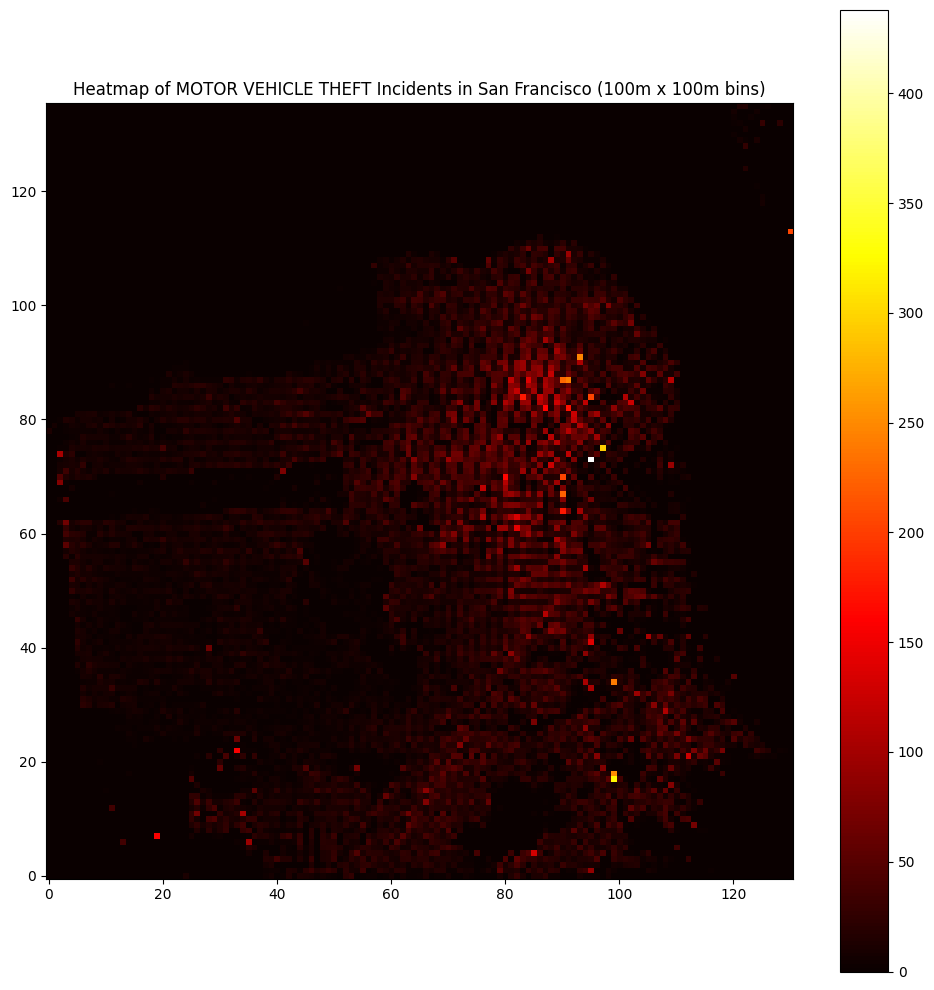

In [23]:
# Review with a plot
plt.figure(figsize=(10,10))
plt.imshow(count, cmap='hot',vmax=count.max(), origin='lower')
plt.colorbar()
plt.title('Heatmap of MOTOR VEHICLE THEFT Incidents in San Francisco (100m x 100m bins)')
plt.tight_layout()
plt.show()

The figure above is a heatmap of MOTOR VEHICLE THEFT incidents in San Francisco. Each cell represents a 100m x 100m area, with color intensity indicating the number of incidents. The contour of the city and the most common crime zones can be seen through the different colors that indicate empty or low values (dark color), and higher crime density (light color) respectively.

### Step 3
*Tally the distribution. Count how many cells have exactly $k$ incidents — call this $N(k)$ — for $k = 0, 1, 2, \ldots$ up to the maximum.*

In [24]:
# Tally N_k — number of cells with exactly k crimes
k_max  = int(flat_counts.max())
k_vals = np.arange(0, k_max + 1)
N_k    = np.array([(flat_counts == k).sum() for k in k_vals])

# Skip k=0 for plotting
k_pos  = k_vals[k_vals >= 1]
Nk_pos = N_k[k_vals >= 1]

# Print some example results
print(f"N_0  (empty cells) : {N_k[0]:,}")
for k in [1, 2, 3, 5, 10]:
    if k <= k_max:
        print(f"N_{k:<3} (k = {k:>3})     : {N_k[k]:,}")
print(f"N_{k_max} (k = {k_max}, max) : {N_k[-1]:,}")

N_0  (empty cells) : 9,235
N_1   (k =   1)     : 387
N_2   (k =   2)     : 423
N_3   (k =   3)     : 436
N_5   (k =   5)     : 399
N_10  (k =  10)     : 303
N_438 (k = 438, max) : 1


### Step 4
*Plot $(k + 1)$ vs $N(k)$ on **linear axes**.*

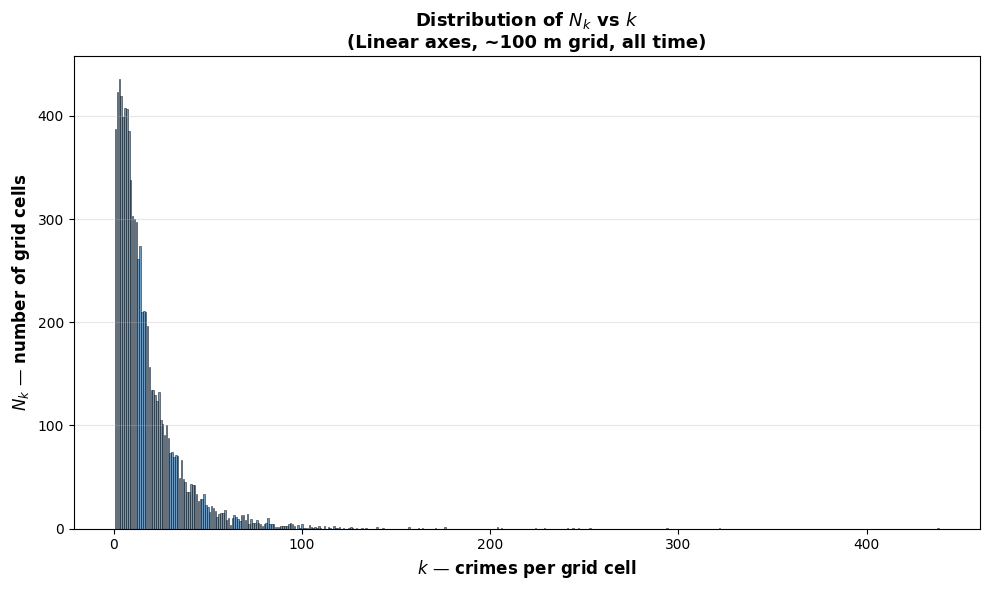

In [25]:
# Plot the distribution of k+1 vs N_k on linear scale but without considering k=0 (empty bins)
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(k_pos, Nk_pos, color='steelblue', edgecolor='black',
       linewidth=0.4, alpha=0.8, width=0.8)
ax.set_xlabel('$k$ — crimes per grid cell', fontsize=12, fontweight='bold')
ax.set_ylabel('$N_k$ — number of grid cells', fontsize=12, fontweight='bold')
ax.set_title(f'Distribution of $N_k$ vs $k$\n(Linear axes, ~{100} m grid, all time)',
             fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The figure is a bar plot showing the distribution of the number of grid cells (N_k) that contain exactly k crimes. The x-axis represents the number of crimes per cell (k), while the y-axis shows how many cells have that count. Empty cells (k=0) are excluded from the plot to focus on areas with crime incidents. It can be seen that most of the cells have low numbers of crimes, but still there are some few cells which have a lot.

### Step 5
*Plot $(k + 1)$ vs $N(k)$ on **loglog axes**.*

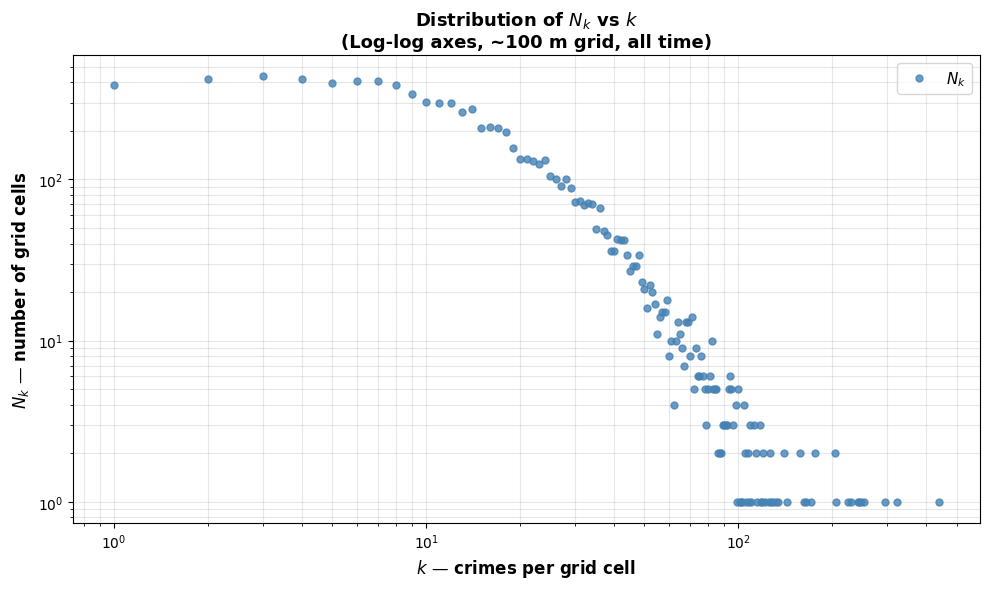

In [26]:
# Plot the distribution of k+1 vs N_k on loglog scale
fig, ax = plt.subplots(figsize=(10, 6))

# Make a mask to avoid plotting points where k=0 or N_k=0 (since log(0) is undefined)
mask = (k_pos >= 1) & (Nk_pos >= 1)

# Configure the plot with log-log axes
ax.plot(k_pos[mask], Nk_pos[mask],
        'o', color='steelblue', markersize=5, alpha=0.8, label='$N_k$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$k$ — crimes per grid cell', fontsize=12, fontweight='bold')
ax.set_ylabel('$N_k$ — number of grid cells', fontsize=12, fontweight='bold')
ax.set_title(f'Distribution of $N_k$ vs $k$\n(Log-log axes, ~{100} m grid, all time)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The figure is a scatter plot showing the distribution of the number of grid cells (N_k) that contain exactly k crimes on a log-log scale. The x-axis represents the number of crimes per cell (k), while the y-axis shows how many cells have that count. This log visualization helps to identify if the distribution follows a power-law or heavy-tailed pattern, which is common in crime data as crimes tends to be concentrated in certain areas.

### Step 6
***Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?***

According to the log-log plot, the Motor Vehicle Theft crime seems to follow an approximate power-law spatial distribution through the downward trend that can be seen in the graph. On the left side of the graph (low crime values), a flat behavior can be seen, meaning that many cells share the low criminality, therefore, deviating from a perfect power law distribution. Also, at the right side of it (high crime), a tail can be seen, which indicates that there are some grid cells which concentrate high "k" (crimes) values, suggesting the presence of hotspots for the selected crime (MOTOR VEHICLE THEFT).

### Step 7
***If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics? Does the "average block" tell you anything useful?***

If crime is concentrated in a few cells, that would imply the presence of hotspots, which could be very valuable at the moment of interpreting neighborhood crime statistics. That concentration could allow governments to make better plans to tackle the crimes, and having that level of statistic detail, can also be useful to save resources in other places which were incorrectly missclasified as prone to commit the crime.

The "average block" can be useful but also misleading. If there is the case that there are these "outliers" (hotspots), then the mean could be very biased and lead to incorrect decisions in terms of policy and safety. In the case of the selected crime (MOTOR VEHICLE THEFT), the distribution follows an approximate power-law which indicate very high crime counts in certain spots. This cause the average statistics to not represent correctly the reality, as many blocks have few crimes, while a few are concentrating a lot. That could lead to the understimation of true hotspots.

## Assignment 1.5: Regression and Correlation

***Select at least 4 of your Personal Focus Crimes for this exercise.***

After looking at the results we all had when doing the weekly exercises, we decided on choosing: DRUG OFFENSE, LIQUOR LAWS, MOTOR VEHICLE THEFT, ROBBERY, STOLEN PROPERTY, WARRANT. The choice was made based on the crimes that we found had the strongest correlations and the discussion that could stem from these results.

In [24]:
categories_to_keep = [
    'DRUG OFFENSE', 'LIQUOR LAWS', 'MOTOR VEHICLE THEFT', 'ROBBERY', 'STOLEN PROPERTY', 'WARRANT'
]

df_focus = df[df['Incident Category'].isin(categories_to_keep)]

***For each selected crime type, compute the total number of incidents for each of the 168 hours of the week (i.e., Monday 00:00–01:00, Monday 01:00–02:00, ..., Sunday 23:00–00:00). Each crime type will give you a vector of 168 values.***

In [25]:
# Create a copy of df to not modify the original
df_weekly = df_focus.copy()

# Convert Incident Date to datetime
df_weekly['Incident Date'] = pd.to_datetime(df_weekly['Incident Date'])

# Convert Incident Time to datetime
df_weekly['Incident Time'] = pd.to_datetime(df_weekly['Incident Time'])

# Extract day of week (0=Monday, 6=Sunday)
df_weekly['DayOfWeek'] = df_weekly['Incident Date'].dt.dayofweek

# Extract hour (0-23)
df_weekly['Hour'] = df_weekly['Incident Time'].dt.hour

# Create hour_of_week identifier (0-167)
# Hour 0 = Monday 00:00-01:00
# Hour 24 = Tuesday 00:00-01:00
# Hour 168 would be Monday again
df_weekly['HourOfWeek'] = df_weekly['DayOfWeek'] * 24 + df_weekly['Hour']

# Group by category and hour_of_week, count incidents
weekly_patterns = df_weekly.groupby(['Incident Category', 'HourOfWeek']).size().reset_index(name='count')

# Create a pivot table with hours as rows and categories as columns
weekly_vectors = weekly_patterns.pivot(index='HourOfWeek', columns='Incident Category', values='count').fillna(0)

# Ensure all 168 hours are present (even if some have 0 incidents)
all_hours = pd.DataFrame({'HourOfWeek': range(168)})
weekly_vectors = all_hours.merge(weekly_vectors, left_on='HourOfWeek', right_index=True, how='left').fillna(0)
weekly_vectors = weekly_vectors.set_index('HourOfWeek')

# Convert to integers
weekly_vectors = weekly_vectors.astype(int)

***Scatterplot matrix: Create a grid of pairwise scatterplots — one panel per pair of crime types, with one crime on each axis and each of the 168 hours as a point. Label each panel clearly with the two crime types being compared.***

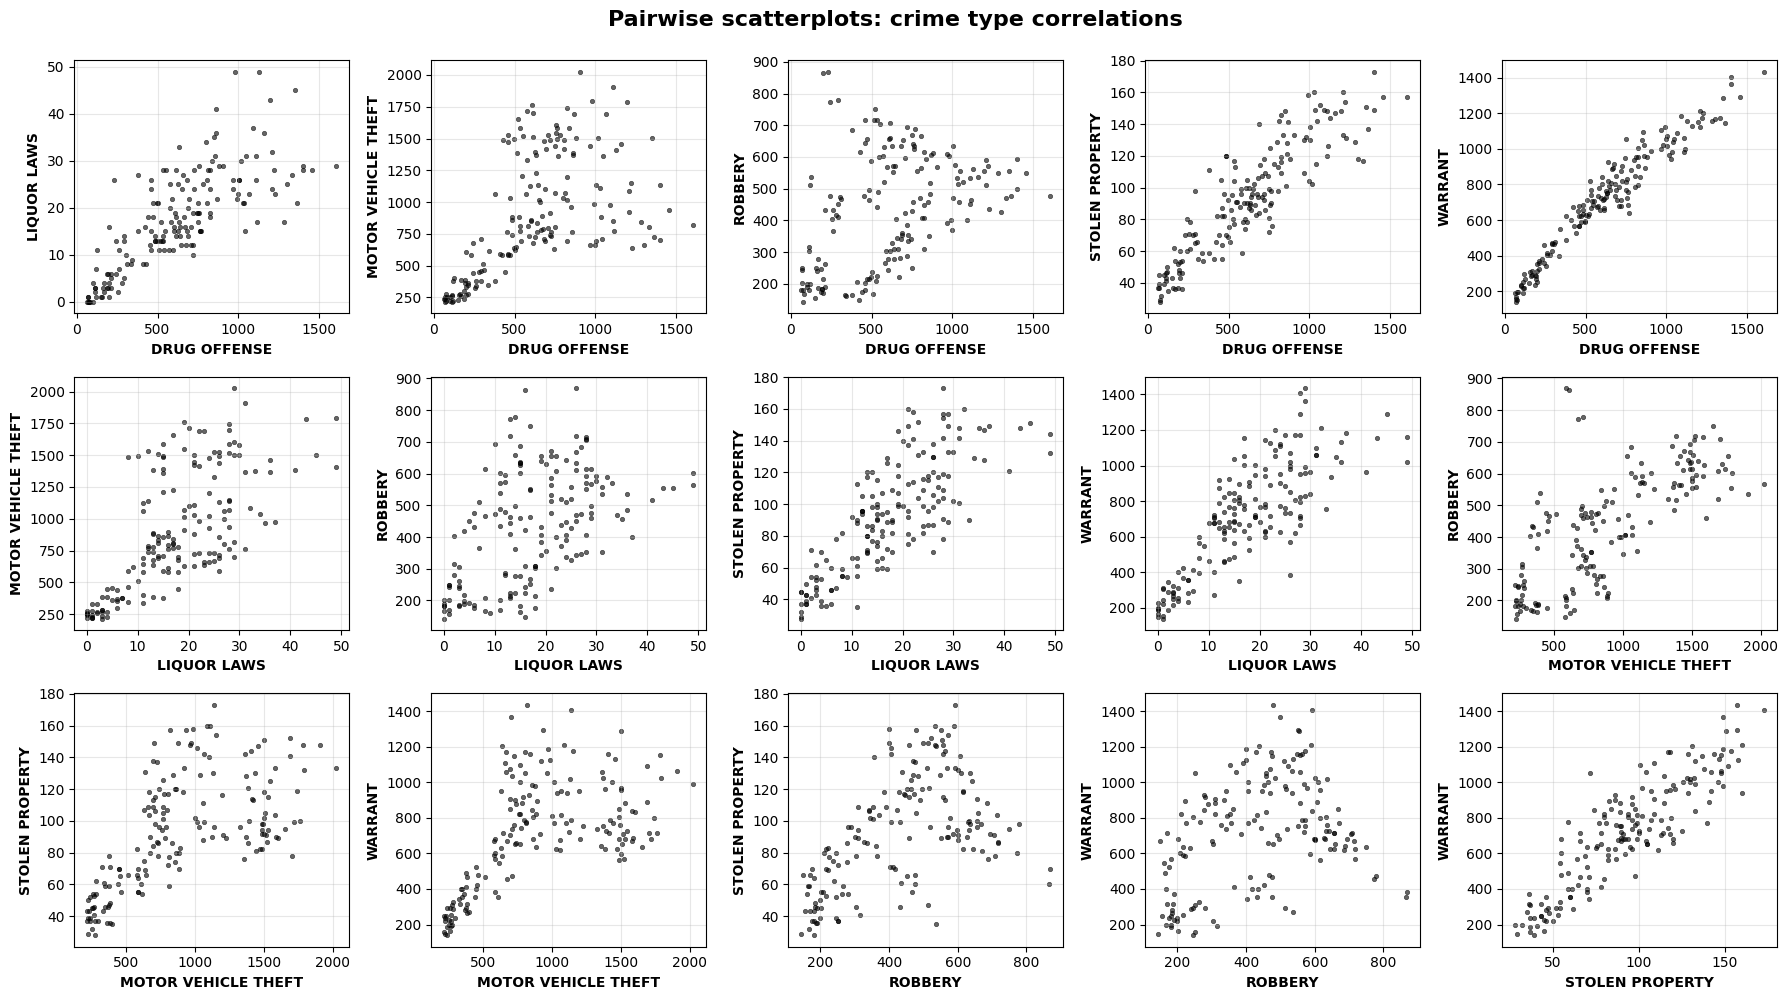

In [26]:
# Get all pairwise combinations of crime categories
crime_types = weekly_vectors.columns.tolist()
pairs = list(combinations(crime_types, 2))

# Create a grid of subplots
# For 15 pairs (6 crimes), we'll use 3 rows × 5 columns
n_pairs = len(pairs)
n_cols = 5
n_rows = int(np.ceil(n_pairs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

# Create a scatterplot for each pair
for idx, (crime1, crime2) in enumerate(pairs):
    ax = axes[idx]
    
    # Get the data for these two crime types
    x = weekly_vectors[crime1].values
    y = weekly_vectors[crime2].values
    hours = weekly_vectors.index.values
    
    # Create scatterplot
    ax.scatter(x, y, s=10, alpha=0.6, edgecolors='black', linewidth=0.5, color='black')
    
    # Add labels and title
    ax.set_xlabel(crime1, fontsize=10, fontweight='bold')
    ax.set_ylabel(crime2, fontsize=10, fontweight='bold')
    
    # Add grid
    ax.grid(True, alpha=0.3)

# Remove extra subplots
for idx in range(n_pairs, len(axes)):
    axes[idx].remove()

plt.suptitle('Pairwise scatterplots: crime type correlations', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

The figure above shows the pairwise correlations for the focus crimes chosen (DRUG OFFENSE, LIQUOR LAWS, MOTOR VEHICLE THEFT, ROBBERY, STOLEN PROPERTY, WARRANT).

***Linear regression: Using the closed-form equations from Week 4 (not a library), fit a regression line to each pair and add it to the relevant panel***

In [27]:
# Compute regression line based on the closed-form equations
def compute_regression_line(x, y):
    """
    Closed-form solution:
        a (slope)     = Σ(xi - x̄)(yi - ȳ) / Σ(xi - x̄)²
        b (intercept) = ȳ - a·x̄
    """
    x_bar = x.mean()
    y_bar = y.mean()
    dx    = x - x_bar
    a     = (dx * (y - y_bar)).sum() / (dx ** 2).sum() if (dx ** 2).sum() != 0 else 0.0
    b     = y_bar - a * x_bar
    return a, b

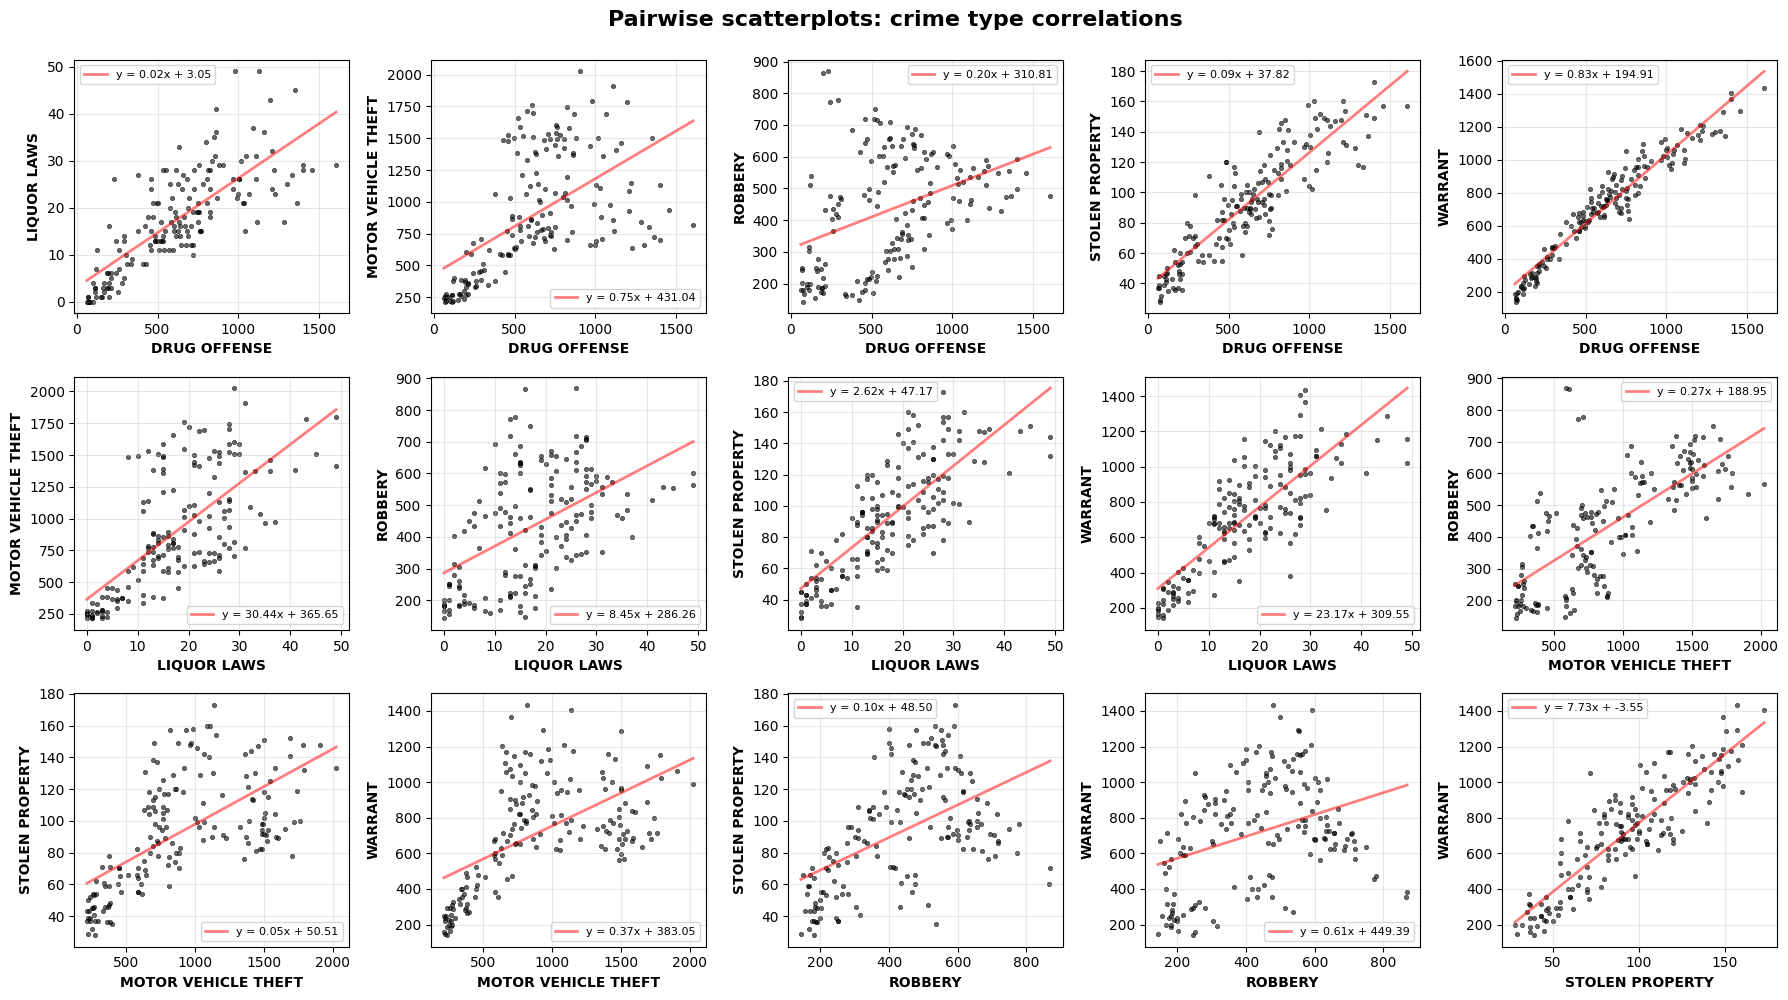

In [28]:
# Get all pairwise combinations of crime categories
crime_types = weekly_vectors.columns.tolist()
pairs = list(combinations(crime_types, 2))

# Create a grid of subplots
# For 15 pairs (6 crimes), we'll use 3 rows × 5 columns
n_pairs = len(pairs)
n_cols = 5
n_rows = int(np.ceil(n_pairs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

# Create a scatterplot for each pair
for idx, (crime1, crime2) in enumerate(pairs):
    ax = axes[idx]
    
    # Get the data for these two crime types
    x = weekly_vectors[crime1].values
    y = weekly_vectors[crime2].values
    hours = weekly_vectors.index.values
    
    # Create scatterplot
    ax.scatter(x, y, s=10, alpha=0.6, edgecolors='black', linewidth=0.5, color='black')
    
    # Compute and plot regression line
    a, b = compute_regression_line(x, y)
    x_min, x_max = x.min(), x.max()
    x_line = np.array([x_min, x_max])
    y_line = a * x_line + b
    ax.plot(x_line, y_line, color='red', linewidth=2, label=f'y = {a:.2f}x + {b:.2f}', alpha=0.5)
    
    # Add labels and title
    ax.set_xlabel(crime1, fontsize=10, fontweight='bold')
    ax.set_ylabel(crime2, fontsize=10, fontweight='bold')
    
    # Add grid
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')

# Remove extra subplots
for idx in range(n_pairs, len(axes)):
    axes[idx].remove()

plt.suptitle('Pairwise scatterplots: crime type correlations', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

The figure above shows the pairwise correlations for the focus crimes chosen (DRUG OFFENSE, LIQUOR LAWS, MOTOR VEHICLE THEFT, ROBBERY, STOLEN PROPERTY, WARRANT) together with the regression line y=ax+b in red. Each of the plots is labeled with the corresponding y line.

***Compute R squared for each pair and display the value on each panel.***

In [29]:
# Computes R squared
def compute_r_squared(x, y):
    """
    R² = 1 - SS_res / SS_tot
    SS_res = Σ(y_i - ŷ_i)²
    SS_tot = Σ(y_i - ȳ)²
    """
    a, b = compute_regression_line(x, y)
    y_pred = a * x + b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot != 0 else 0.0

C:\Users\ogonz\AppData\Local\Temp\ipykernel_39344\459367275.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='best')


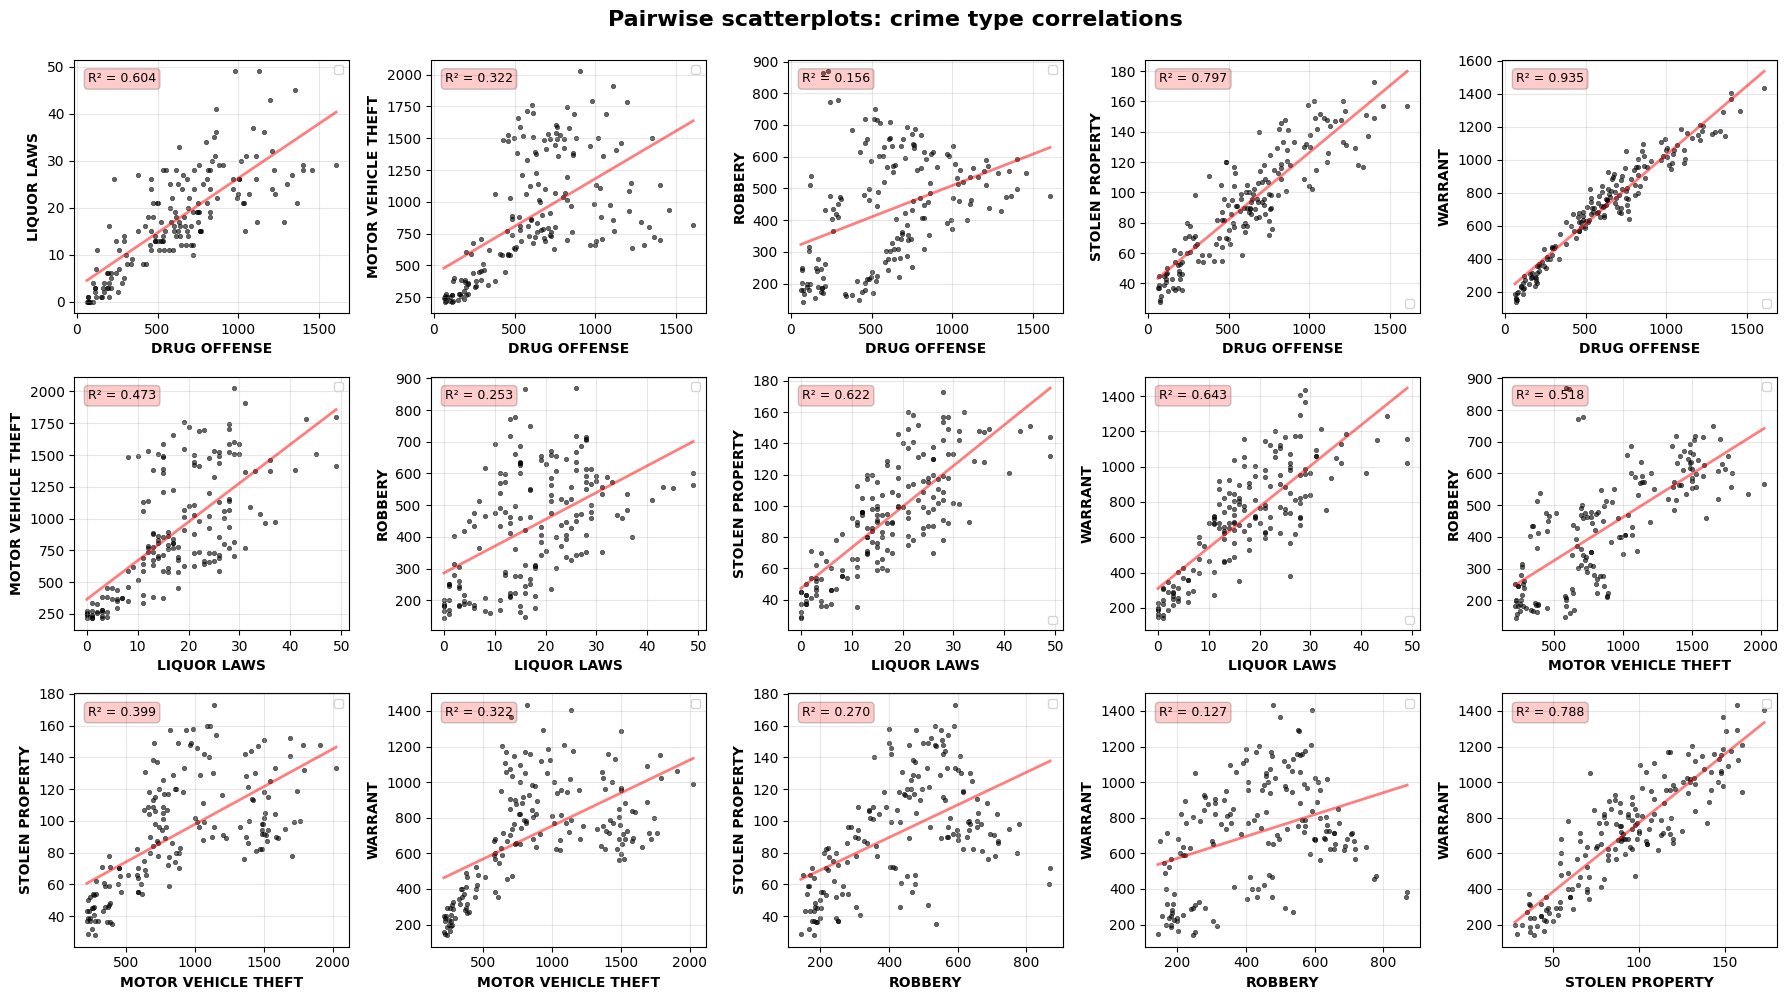

In [30]:
# Get all pairwise combinations of crime categories
crime_types = weekly_vectors.columns.tolist()
pairs = list(combinations(crime_types, 2))

# Create a grid of subplots
# For 15 pairs (6 crimes), we'll use 3 rows × 5 columns
n_pairs = len(pairs)
n_cols = 5
n_rows = int(np.ceil(n_pairs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

# Create a scatterplot for each pair
for idx, (crime1, crime2) in enumerate(pairs):
    ax = axes[idx]
    
    # Get the data for these two crime types
    x = weekly_vectors[crime1].values
    y = weekly_vectors[crime2].values
    hours = weekly_vectors.index.values
    
    # Create scatterplot
    ax.scatter(x, y, s=10, alpha=0.6, edgecolors='black', linewidth=0.5, color='black')
    
    # Compute and plot regression line
    a, b = compute_regression_line(x, y)
    x_min, x_max = x.min(), x.max()
    x_line = np.array([x_min, x_max])
    y_line = a * x_line + b
    ax.plot(x_line, y_line, color='red', linewidth=2, alpha=0.5)
    
    # Compute and display R²
    r_squared = compute_r_squared(x, y)
    ax.text(0.05, 0.95, f'R² = {r_squared:.3f}', transform=ax.transAxes, 
            fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='red', alpha=0.2))
    
    # Add labels and title
    ax.set_xlabel(crime1, fontsize=10, fontweight='bold')
    ax.set_ylabel(crime2, fontsize=10, fontweight='bold')
    
    # Add grid
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')

# Remove extra subplots
for idx in range(n_pairs, len(axes)):
    axes[idx].remove()

plt.suptitle('Pairwise scatterplots: crime type correlations', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

The figure above shows the pairwise correlations for the focus crimes chosen (DRUG OFFENSE, LIQUOR LAWS, MOTOR VEHICLE THEFT, ROBBERY, STOLEN PROPERTY, WARRANT) together with the regression line y=ax+b in red. Each of the plots is labeled with the corresponding R squared value.

***Looking at your results: which pair of crimes is most correlated? Which is least correlated? Does the answer match your intuition? Why might two crime types share a weekly rhythm — or not?***

Based on our results, the most correlated crimes are WARRANT and DRUG OFFENSE which reinforces the idea presented in the beginning of the course reagrding police surveillance being concentrated in certain neighbourhoods - in this case it could suggest that neighbourhoods which have a high drug activity are more likely to have a higher police presence, this leading to more warrants being issued.

A similar correlation is present between LIQUOR LAWS and WARRANT.

Another aspect we were expecting is that addictions are correlated, as seen in the plot for LIQUOR LAWS and DRUG OFFENSE.

The least correlated crimes are ROBBERY and WARRANT which could be explained by the intuition that the richer neighbourhoods which have less warrants issued overall are the ones being primarily attacked by robbers.

## Collaboration

We started by comparing the results we had from the weekly exercises and deciding on the focus crimes together. We continued by dividing the work as such:
* Babeii Denisa (s253528) - Dataset preprocessing and merging + Assignment 1.5
* Hinojosa Omar González (s231439) - Assignment 1.3 + 1.4
* Ilves Ursula (s254332) - Assignment 1.1 + 1.2